# Day 2:  <font color = "red">**Structure → Property Challenge**</font>

Can local image structure predict the local EELS response?

For each location, we have:

**Image patch → EELS spectrum → Scalarizer**

Your task is to:

1. Build a <font color = "purple">**descriptor**</font> for the image patch.
2. Use a <font color = "purple">**regressor**</font> to predict a scalarizer or the full spectrum.
3. Compare methods by:
   - predictive power
   - complexity
   - explainability

<font color = "green">**Goal**</font>

> Find the simplest explainable descriptor that predicts the EELS response well.

## <font color = "purple">**1.**</font> Explore the Dataset

Each spatial location contains:

- one image intensity value
- one full EELS spectrum

The same position in the image corresponds to the same position in the EELS spectrum image.

Let's look at one dataset.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_17_18092026/notebook.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import os

In [ ]:
#!gdown --fuzzy 1FKmlRTRDImQS91V4YQjcQHoJU19X6P_6

usage: gdown [-h] [-V] [-O OUTPUT] [-q] [--proxy PROXY] [--speed SPEED]
             [--cookies FILE] [--cookies-from-browser BROWSER] [--no-cookies]
             [--no-check-certificate] [--continue] [--folder] [--json]
             [--format FORMAT] [--user-agent USER_AGENT]
             url_or_id
gdown: error: unrecognized arguments: --fuzzy


In [2]:
file_name = "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_17_18092026/Plasmonic_sets_hackathon.npy"#"/content/Plasmonic_sets_hackathon.npy"

raw = np.load(
    file_name,
    allow_pickle=True
)

loadedfile = raw.tolist()
print("keys:", loadedfile.keys())

keys: dict_keys(['0', '1', '2', '3'])


In [3]:
# Choose dataset
data = loadedfile["2"]

image = data["image"]
spectra = data["spectrum image"]
energy = data["energy axis"]

H, W = image.shape

print(image.shape)
print(spectra.shape)
print(energy.shape)

(33, 63)
(33, 63, 4322)
(4322,)


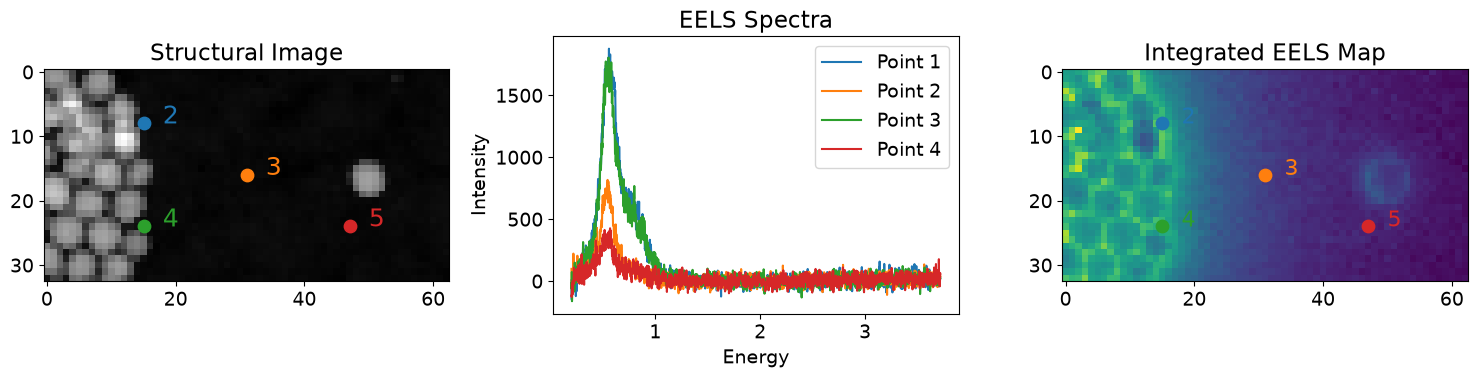

In [4]:
# Example locations
positions = [
    (H // 4, W // 4),
    (H // 2, W // 2),
    (3 * H // 4, W // 4),
    (3 * H // 4, 3 * W // 4),
]

colors = ["C0", "C1", "C2", "C3"]

# Integrated EELS map
eels_map = spectra.sum(axis=2)

plt.rcParams.update({"font.size": 14})

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Structural image
ax[0].imshow(image, cmap="gray")
ax[0].set_title("Structural Image")

# Spectra
for i, ((y, x), color) in enumerate(zip(positions, colors)):
    
    ax[0].scatter(x, y, s=80, color=color)
    ax[0].text(x + 3, y, str(i + 2), color=color, fontsize=18)

    ax[1].plot(
        energy,
        spectra[y, x],
        color=color,
        label=f"Point {i + 1}"
    )

    ax[2].scatter(x, y, s=80, color=color)
    ax[2].text(x + 3, y, str(i + 2), color=color, fontsize=16)

ax[1].set_title("EELS Spectra")
ax[1].set_xlabel("Energy")
ax[1].set_ylabel("Intensity")
ax[1].legend()

# EELS map
ax[2].imshow(eels_map)
ax[2].set_title("Integrated EELS Map")

plt.tight_layout()
plt.show()

## <font color = "purple">**2.**</font> Define a Scalarizer

Each EELS spectrum can be reduced to a **single target value** called a scalarizer.

For example, the spectral intensity within an energy window:

$$
S(x,y)=\int_{E_1}^{E_2} I(x,y,E)\,dE
$$

where \(E_1\) and \(E_2\) define the spectral region of interest.

Other possible scalarizers include:

- peak intensity
- peak position
- peak area
- peak ratio

## <font color = "purple">**3.**</font> Choose a Spectral Region

Before defining the scalarizer, inspect the EELS spectrum and choose an energy range containing a feature of interest.

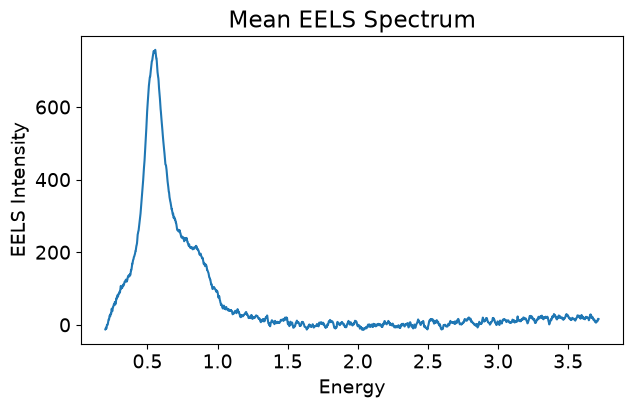

In [5]:
# Mean spectrum over the whole image
mean_spectrum = spectra.mean(axis=(0, 1))

plt.figure(figsize=(7, 4))

plt.plot(energy, mean_spectrum)

plt.xlabel("Energy")
plt.ylabel("EELS Intensity")
plt.title("Mean EELS Spectrum")

plt.show()

## <font color = "purple">**4.**</font> Calculate the Scalarizer

We integrate the EELS intensity inside the selected energy window to obtain one target value at each spatial location.

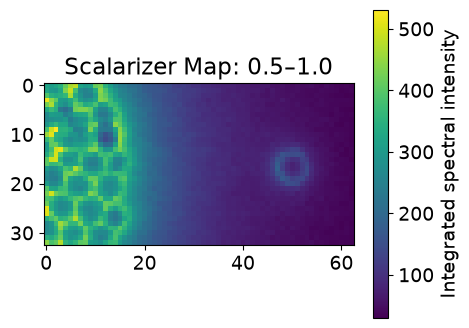

In [6]:
# Choose an energy range
E1 = 0.5
E2 = 1.0

mask = (energy >= E1) & (energy <= E2)

scalarizer_map = np.trapezoid(
    spectra[:, :, mask],
    energy[mask],
    axis=2
)

plt.figure(figsize=(5, 4))
plt.imshow(scalarizer_map)
plt.colorbar(label="Integrated spectral intensity")
plt.title(f"Scalarizer Map: {E1}–{E2}")
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Use the local file if it sits next to the notebook, otherwise the Colab path.
local_file = file_name
colab_file = "/content/Plasmonic_sets_hackathon.npy"
file_name = local_file if os.path.exists(local_file) else colab_file

loadedfile = np.load(file_name, allow_pickle=True).tolist()
print("keys:", loadedfile.keys())

data    = loadedfile["2"]
image   = np.asarray(data["image"], dtype=float)
spectra = np.asarray(data["spectrum image"], dtype=float)
energy  = np.asarray(data["energy axis"], dtype=float)

H, W = image.shape
print("image:", image.shape, " spectra:", spectra.shape, " energy:", energy.shape)

# Put the image on a common scale so descriptors do not depend on detector units.
image_n = (image - image.mean()) / (image.std() + 1e-12)

keys: dict_keys(['0', '1', '2', '3'])
image: (33, 63)  spectra: (33, 63, 4322)  energy: (4322,)


In [16]:
import numpy as np
from scipy.ndimage import (uniform_filter, maximum_filter, minimum_filter,
                           gaussian_filter, gaussian_laplace, convolve,
                           distance_transform_edt)
from skimage.filters import threshold_otsu
from skimage.measure import find_contours
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.morphology import remove_small_objects


# ---------- sizes that fit a 33 x 63 image ----------
RING_EDGES = (0, 2, 4, 8)   # largest ring is 8 px, about a quarter of the short side
BORDER     = 4              # rows and columns skipped at the edges
LOG_SCALES = (1, 2, 4)      # blob scales that fit inside the image


# ---------- rotationally invariant multi-scale sampling ----------

def _ring_kernel(r_in, r_out):
    """A flat ring (annulus) kernel, normalised so it computes an average."""
    R = int(np.ceil(r_out))
    yy, xx = np.mgrid[-R:R + 1, -R:R + 1]
    rr = np.sqrt(yy ** 2 + xx ** 2)
    k = ((rr >= r_in) & (rr <= r_out)).astype(float)
    return k / k.sum()


def ring_maps(img, edges=RING_EDGES):
    """Average intensity in rings of growing radius around every pixel.

    Rings are isotropic, so the descriptor does not care how the sample
    is rotated. Growing radii look further and further away.
    """
    return {f"ring_{a}_{b}": convolve(img, _ring_kernel(a, b), mode="reflect")
            for a, b in zip(edges[:-1], edges[1:])}


# ---------- simple local statistics (the starter descriptor, as maps) ----------

def local_stat_maps(img, size=5):
    mean = uniform_filter(img, size)
    var = uniform_filter(img ** 2, size) - mean ** 2
    return {
        f"mean_{size}":  mean,
        f"std_{size}":   np.sqrt(np.clip(var, 0, None)),
        f"range_{size}": maximum_filter(img, size) - minimum_filter(img, size),
    }


# ---------- segmentation ----------

def segment_particles(img, smooth=1.0, min_distance=2, min_size=10):
    """Find the individual particles, not just metal against vacuum.

    Otsu fills the dark channels between touching particles, so the distance
    transform has nothing left to split. Instead the bright centres are used
    as seeds and watershed grows each particle down the intensity slope.

    watershed_line=True leaves a one pixel gap between neighbours, which is
    what makes per-particle distances possible below.

    Returns:
      labels  - 0 in vacuum and on the separating lines, 1..N inside particles
      cluster - True anywhere on metal, channels between particles included
    """
    sm = gaussian_filter(img, smooth)
    cluster = remove_small_objects(sm > threshold_otsu(sm), min_size)

    peaks = peak_local_max(sm, min_distance=min_distance, labels=cluster,
                           exclude_border=False)
    markers = np.zeros(cluster.shape, dtype=int)
    markers[tuple(peaks.T)] = np.arange(1, len(peaks) + 1)

    labels = watershed(-sm, markers, mask=cluster, watershed_line=True)
    return labels, cluster


def curvature_map(binary, smooth=2.0):
    """Boundary curvature, copied from the nearest boundary point to every pixel.

    Sharp corners concentrate the field (the lightning-rod effect).
    """
    curv = np.zeros(binary.shape, dtype=float)
    edge = np.zeros(binary.shape, dtype=bool)

    for contour in find_contours(gaussian_filter(binary.astype(float), smooth), 0.5):
        y, x = contour[:, 0], contour[:, 1]
        dy, dx = np.gradient(y), np.gradient(x)
        ddy, ddx = np.gradient(dy), np.gradient(dx)
        k = (dx * ddy - dy * ddx) / (dx ** 2 + dy ** 2 + 1e-9) ** 1.5

        yi = np.clip(np.round(y).astype(int), 0, binary.shape[0] - 1)
        xi = np.clip(np.round(x).astype(int), 0, binary.shape[1] - 1)
        curv[yi, xi] = k
        edge[yi, xi] = True

    if not edge.any():
        return curv
    _, idx = distance_transform_edt(~edge, return_indices=True)
    return curv[idx[0], idx[1]]


def particle_geometry_maps(labels, cluster):
    """Geometry at two length scales: the single particle and the whole cluster."""
    maps = {}
    n = int(labels.max())
    inside = labels > 0

    # ---- particle scale ----
    # Distance to the surface of your own particle, positive inside.
    maps["d_particle"] = (distance_transform_edt(inside)
                          - distance_transform_edt(~inside))

    # Distance to the two nearest particles, added together.
    # Small where two particles almost touch: the junctions and hot spots.
    if n > 1:
        D = np.sort(np.stack([distance_transform_edt(labels != i)
                              for i in range(1, n + 1)]), axis=0)
        maps["gap"] = D[0] + D[1]
    else:
        maps["gap"] = np.zeros(labels.shape)

    # Size of the particle you belong to, or of the nearest one.
    radius = np.sqrt(np.bincount(labels.ravel()) / np.pi)
    _, idx = distance_transform_edt(~inside, return_indices=True)
    maps["particle_radius"] = radius[labels[idx[0], idx[1]]]

    # How many particle centres sit within 10 px: how embedded you are.
    centres = np.zeros(labels.shape)
    for i in range(1, n + 1):
        ys, xs = np.nonzero(labels == i)
        centres[int(round(ys.mean())), int(round(xs.mean()))] = 1
    maps["coordination"] = convolve(centres, (_ring_kernel(0, 10) > 0).astype(float),
                                    mode="constant")

    # ---- cluster scale ----
    maps["d_cluster"] = (distance_transform_edt(cluster)
                         - distance_transform_edt(~cluster))
    maps["cluster_curvature"] = curvature_map(cluster)

    return maps


# ---------- assemble ----------

def build_feature_maps(img, labels, cluster, ring_edges=RING_EDGES):
    """Return a dictionary: descriptor name -> H x W map."""
    maps = {}
    maps.update(local_stat_maps(img, size=5))
    maps.update(ring_maps(img, edges=ring_edges))
    maps["mask"] = cluster.astype(float)
    maps.update(particle_geometry_maps(labels, cluster))
    for s in LOG_SCALES:
        maps[f"log_{s}"] = -gaussian_laplace(img, s) * s ** 2
    return maps


LABELS, CLUSTER = segment_particles(image_n)
mask = CLUSTER
FEATURE_MAPS = build_feature_maps(image_n, LABELS, CLUSTER)

print(f"{LABELS.max()} particles, {len(FEATURE_MAPS)} maps")
print(list(FEATURE_MAPS))


REPRESENTATIONS = {
    "starter_5x5":    ["mean_5", "std_5", "range_5"],
    "brightness":     [k for k in FEATURE_MAPS if k.startswith("ring_")],
    "particle_scale": ["d_particle", "gap", "particle_radius"],
    "cluster_scale":  ["d_cluster", "cluster_curvature"],
    "both_scales":    ["d_particle", "gap", "d_cluster"],
    "minimal":        ["d_particle", "d_cluster"],
}

19 particles, 16 maps
['mean_5', 'std_5', 'range_5', 'ring_0_2', 'ring_2_4', 'ring_4_8', 'mask', 'd_particle', 'gap', 'particle_radius', 'coordination', 'd_cluster', 'cluster_curvature', 'log_1', 'log_2', 'log_4']


/var/folders/bc/5_vf1n1s61df21xwx7889ld00000gn/T/ipykernel_82954/4189448461.py:68: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cluster = remove_small_objects(sm > threshold_otsu(sm), min_size)


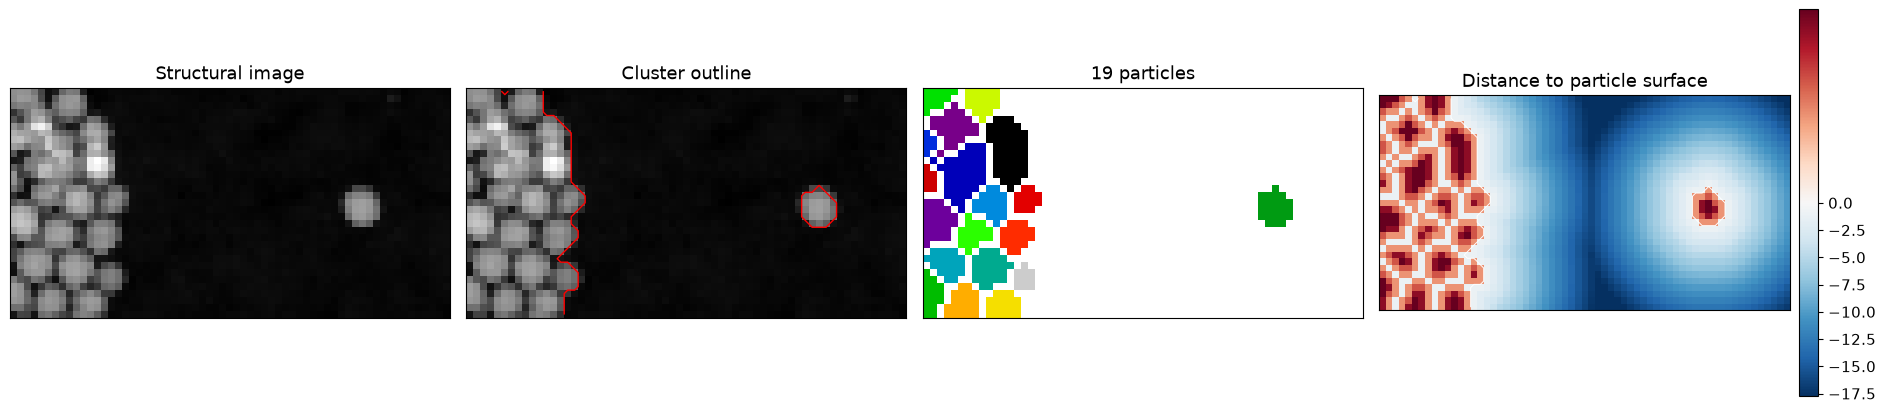

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.rcParams.update({"font.size": 11, "figure.facecolor": "white"})


def _is_signed(a, frac=0.02):
    """True if the map has a meaningful amount of both positive and negative values."""
    finite = a[np.isfinite(a)]
    if finite.size == 0:
        return False
    return (finite < 0).mean() > frac and (finite > 0).mean() > frac


from matplotlib.colors import TwoSlopeNorm, Normalize


def show_map(ax, m, title, mask=None, robust=(2, 98)):
    """Draw one feature map with a sensible colour scale.

    Signed maps get a diverging scale with white exactly at zero, so the sign
    is readable. Everything else gets a single-hue scale.
    Limits are percentiles so a few extreme pixels do not wash out the map.
    """
    finite = m[np.isfinite(m)]
    if finite.size == 0:                       # nothing to show
        ax.axis("off")
        return None

    lo, hi = np.nanpercentile(finite, robust)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(finite.min()), float(finite.max())
    if hi <= lo:                               # constant map
        lo, hi = lo - 0.5, hi + 0.5

    if _is_signed(m) and lo < 0 < hi:
        # White sits exactly at zero, and each side keeps its own range.
        norm = TwoSlopeNorm(vcenter=0.0, vmin=lo, vmax=hi)
        im = ax.imshow(m, cmap="RdBu_r", norm=norm)
    else:
        im = ax.imshow(m, cmap="viridis", norm=Normalize(vmin=lo, vmax=hi))

    # Draw the particle outline on top so every map is read against the geometry.
    if mask is not None:
        ax.contour(mask.astype(float), levels=[0.5], colors="w", linewidths=0.7)

    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    return im


# ---- first thing to check: did the segmentation actually work? ----
mask = FEATURE_MAPS["mask"] > 0.5

fig, ax = plt.subplots(1, 4, figsize=(19, 4.2))

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Structural image")

ax[1].imshow(image, cmap="gray")
ax[1].contour(mask.astype(float), levels=[0.5], colors="r", linewidths=1.0)
ax[1].set_title("Cluster outline")

# Each particle in its own colour: this is what the new segmentation buys you.
ax[2].imshow(np.where(LABELS > 0, LABELS, np.nan), cmap="nipy_spectral")
ax[2].set_title(f"{LABELS.max()} particles")

for a in ax[:3]:
    a.set_xticks([]); a.set_yticks([])

show_map(ax[3], FEATURE_MAPS["d_particle"],
         "Distance to particle surface", mask=mask)

plt.tight_layout(); plt.show()


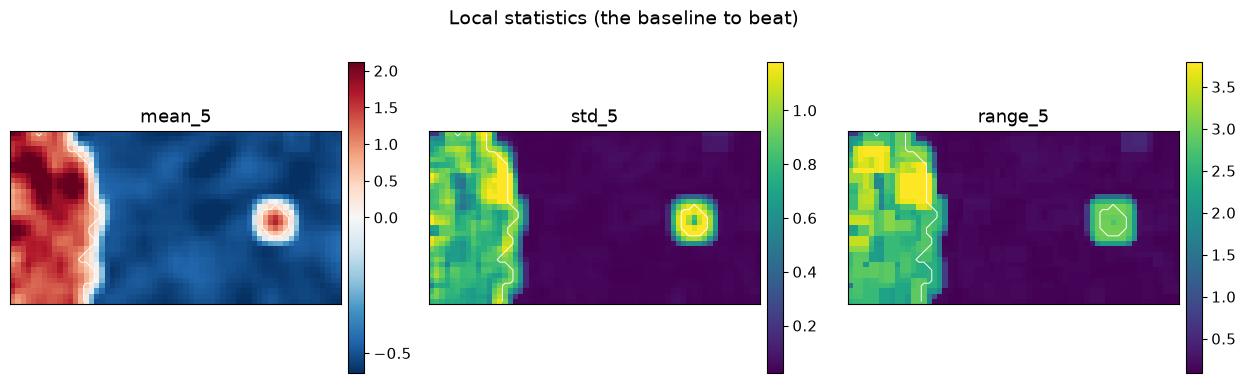

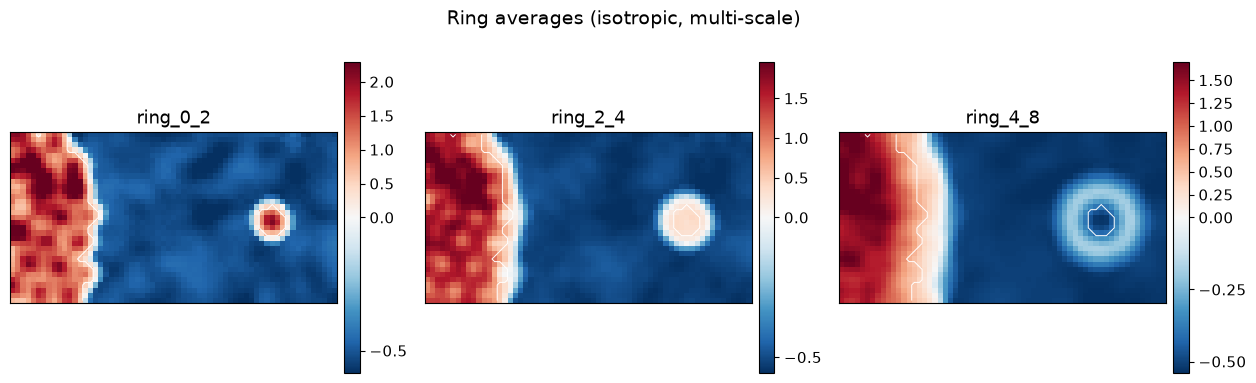

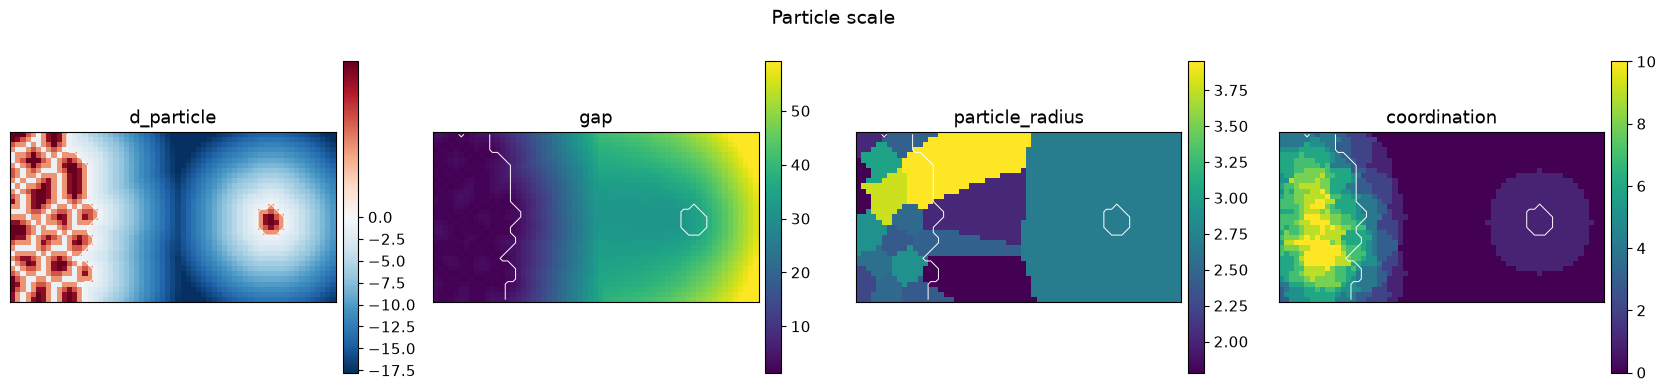

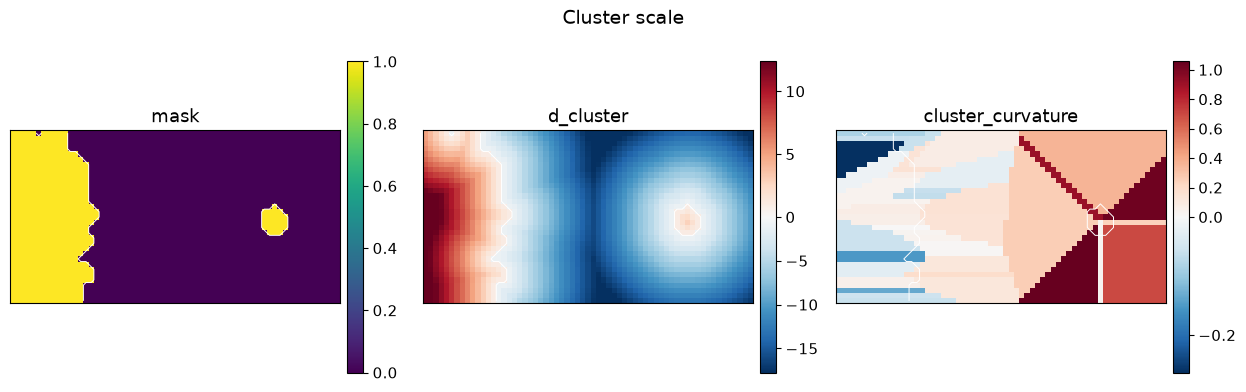

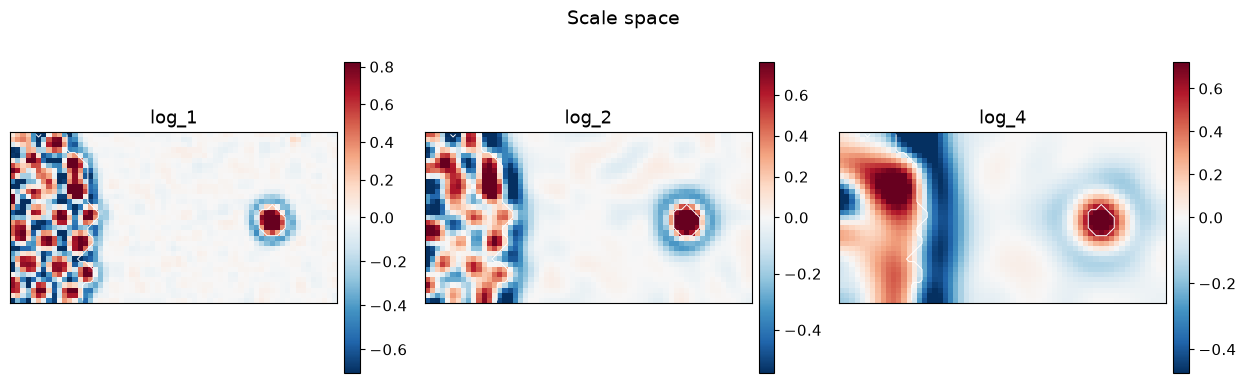

In [19]:
def show_group(names, title, ncols=4, mask=mask):
    """Plot a set of feature maps in a grid."""
    names = [n for n in names if n in FEATURE_MAPS]
    nrows = int(np.ceil(len(names) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for a, n in zip(axes, names):
        show_map(a, FEATURE_MAPS[n], n, mask=mask)
    for a in axes[len(names):]:
        a.axis("off")

    fig.suptitle(title, fontsize=14, y=1.0)
    plt.tight_layout(); plt.show()


show_group(["mean_5", "std_5", "range_5"],
           "Local statistics (the baseline to beat)", ncols=3)

show_group([k for k in FEATURE_MAPS if k.startswith("ring_")],
           "Ring averages (isotropic, multi-scale)", ncols=3)

show_group(["d_particle", "gap", "particle_radius", "coordination"],
           "Particle scale", ncols=4)

show_group(["mask", "d_cluster", "cluster_curvature"],
           "Cluster scale", ncols=3)

show_group([k for k in FEATURE_MAPS if k.startswith("log_")],
           "Scale space", ncols=3)

In [20]:
from scipy.ndimage import gaussian_filter1d

# The zero-loss peak is already removed in this dataset: the axis starts at
# 0.200 eV and the peak near 0.56 eV is the plasmon. So do not cut it away.
E_MIN, E_MAX = energy.min(), 1.5        # above 1.5 eV this set is mostly noise

sel = (energy >= E_MIN) & (energy <= E_MAX)
E = energy[sel]
I = spectra[:, :, sel]                   # keep the negative values, they are
                                         # background-subtraction residuals and
                                         # removing them would bias the area

integrate = getattr(np, "trapezoid", None) or np.trapz

# Smooth along energy before looking for the peak. The step is 0.0008 eV, so the
# raw maximum is dominated by noise; 15 channels is about 0.012 eV.
Is = gaussian_filter1d(I, sigma=15, axis=2)

peak_I = Is.max(axis=2)
peak_E = E[np.argmax(Is, axis=2)]

# Width at half height, measured on the smoothed spectrum.
fwhm = ((Is > peak_I[:, :, None] / 2.0) * np.gradient(E)[None, None, :]).sum(axis=2)

area = integrate(I, E, axis=2)

# Weight of a narrow window around the main mode versus the tail above it.
def _band(lo, hi):
    m = (E >= lo) & (E <= hi)
    return integrate(I[:, :, m], E[m], axis=2)

SPECTRAL_TARGETS = {
    "area":       area,                    # oscillator strength
    "peak_E":     peak_E,                  # resonance energy
    "peak_I":     peak_I,                  # resonance amplitude
    "fwhm":       fwhm,                    # damping
    "Q":          peak_E / (fwhm + 1e-12), # sharpness of the mode
    "band_ratio": _band(0.4, 0.7) / (_band(0.7, 1.2) + 1e-12),
}

print("targets:", list(SPECTRAL_TARGETS))
print("peak_E range: %.3f .. %.3f eV" % (peak_E.min(), peak_E.max()))

targets: ['area', 'peak_E', 'peak_I', 'fwhm', 'Q', 'band_ratio']
peak_E range: 0.500 .. 0.864 eV


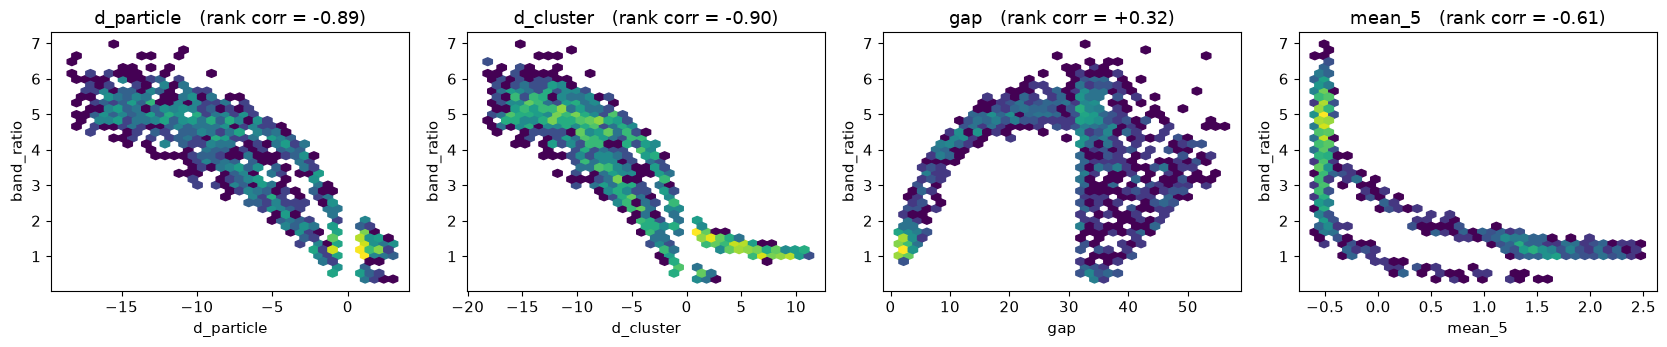

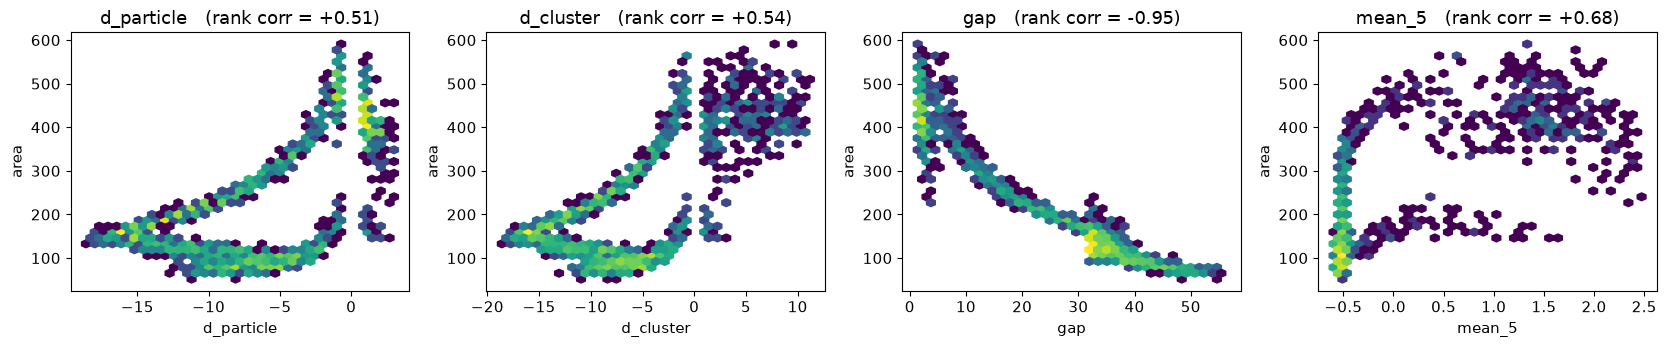

                   area  peak_E  peak_I  fwhm     Q  band_ratio
d_cluster          0.54    0.54    0.34  0.74 -0.67       -0.90
d_particle         0.51    0.55    0.32  0.73 -0.64       -0.89
ring_4_8           0.63    0.52    0.48  0.65 -0.60       -0.77
coordination       0.58    0.52    0.44  0.65 -0.61       -0.75
ring_2_4           0.70    0.59    0.52  0.65 -0.57       -0.66
std_5              0.54    0.54    0.35  0.58 -0.49       -0.62
range_5            0.57    0.54    0.37  0.60 -0.51       -0.62
mean_5             0.68    0.58    0.49  0.61 -0.53       -0.61
ring_0_2           0.66    0.57    0.48  0.58 -0.50       -0.58
log_4              0.27    0.33    0.01  0.45 -0.40       -0.43
mask               0.42    0.36    0.27  0.43 -0.41       -0.38
gap               -0.95   -0.61   -0.90 -0.38  0.33        0.32
particle_radius   -0.06    0.03   -0.14  0.19 -0.21       -0.20
cluster_curvature -0.83   -0.48   -0.80 -0.25  0.22        0.12
log_1             -0.13   -0.01   -0.17 

In [ ]:
import pandas as pd


def feature_vs_target(names, target_name, border=BORDER, gridsize=35):
    """Each feature against the measured target, as a density map.

    A clear trend means the feature carries real information.
    A shapeless cloud means it does not, whatever a regressor later reports.
    """
    target = SPECTRAL_TARGETS[target_name]
    sl = (slice(border, H - border), slice(border, W - border))
    y = target[sl].ravel()

    ncols = min(4, len(names))
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for a, n in zip(axes, names):
        x = FEATURE_MAPS[n][sl].ravel()
        ok = np.isfinite(x) & np.isfinite(y)
        a.hexbin(x[ok], y[ok], gridsize=gridsize, cmap="viridis", bins="log")

        # Rank correlation: catches trends that are not straight lines.
        r = np.corrcoef(np.argsort(np.argsort(x[ok])),
                        np.argsort(np.argsort(y[ok])))[0, 1]
        a.set_title(f"{n}   (rank corr = {r:+.2f})")
        a.set_xlabel(n); a.set_ylabel(target_name)

    for a in axes[len(names):]:
        a.axis("off")

    plt.tight_layout(); plt.show()


def rank_table(border=BORDER):
    """Rank correlation of every feature map with every spectral target."""
    sl = (slice(border, H - border), slice(border, W - border))

    def rc(a, b):
        a, b = a[sl].ravel(), b[sl].ravel()
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() < 10 or np.std(a[ok]) == 0:
            return np.nan
        return np.corrcoef(np.argsort(np.argsort(a[ok])),
                           np.argsort(np.argsort(b[ok])))[0, 1]

    return pd.DataFrame(
        {t: {f: rc(FEATURE_MAPS[f], SPECTRAL_TARGETS[t]) for f in FEATURE_MAPS}
         for t in SPECTRAL_TARGETS}
    ).round(2)


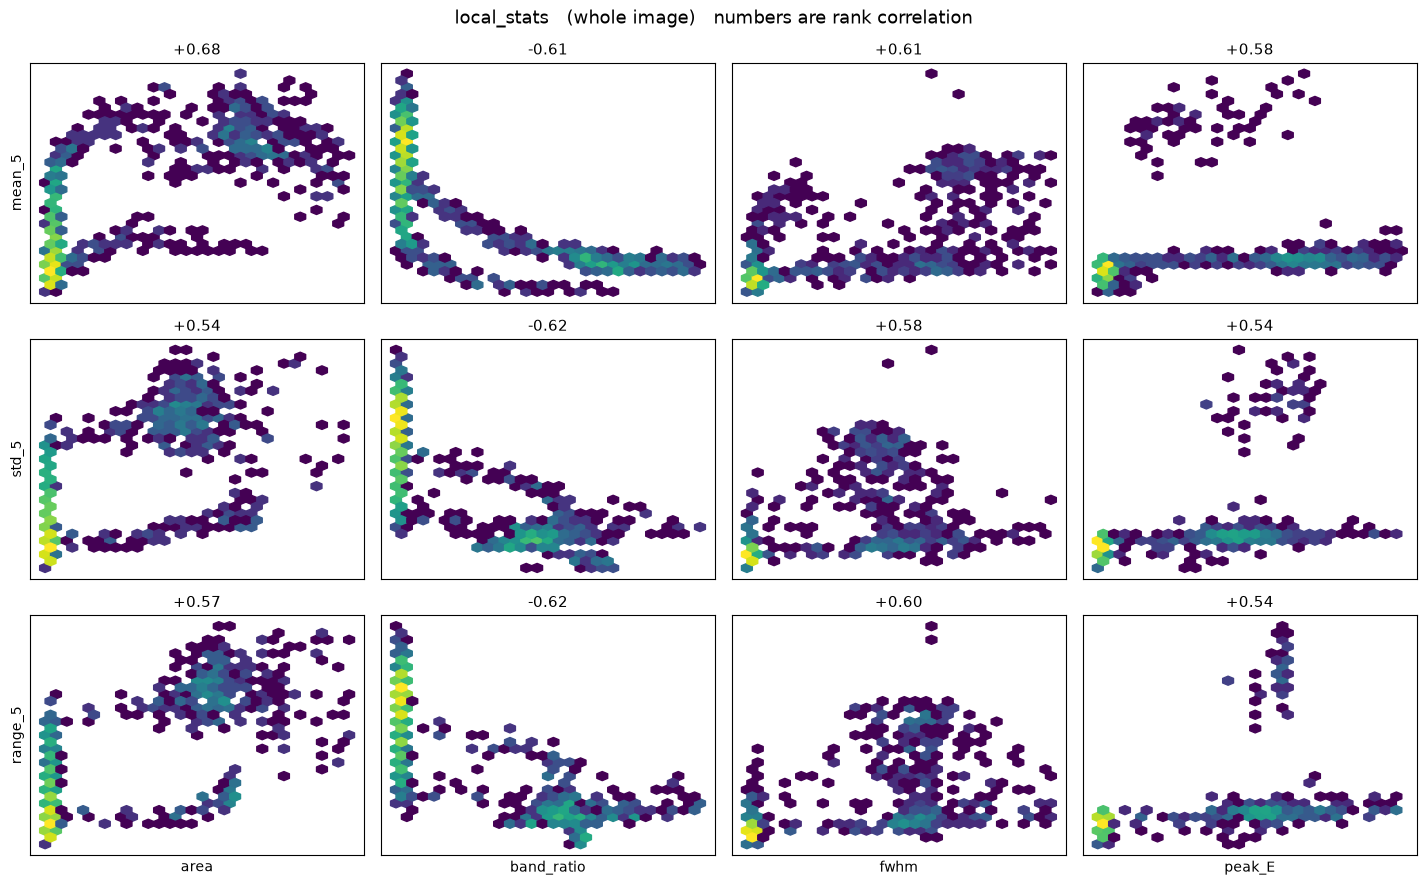

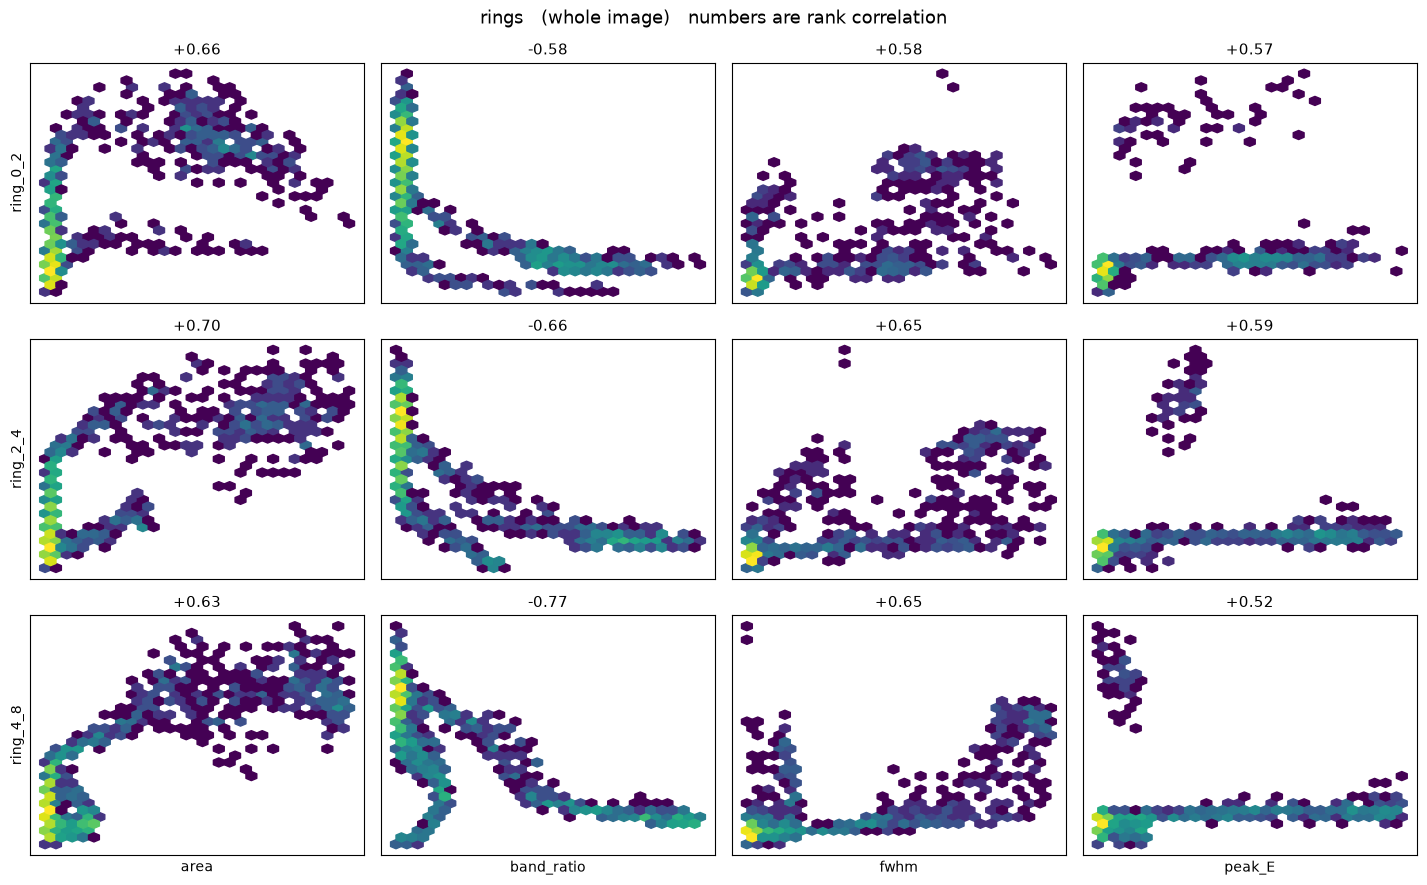

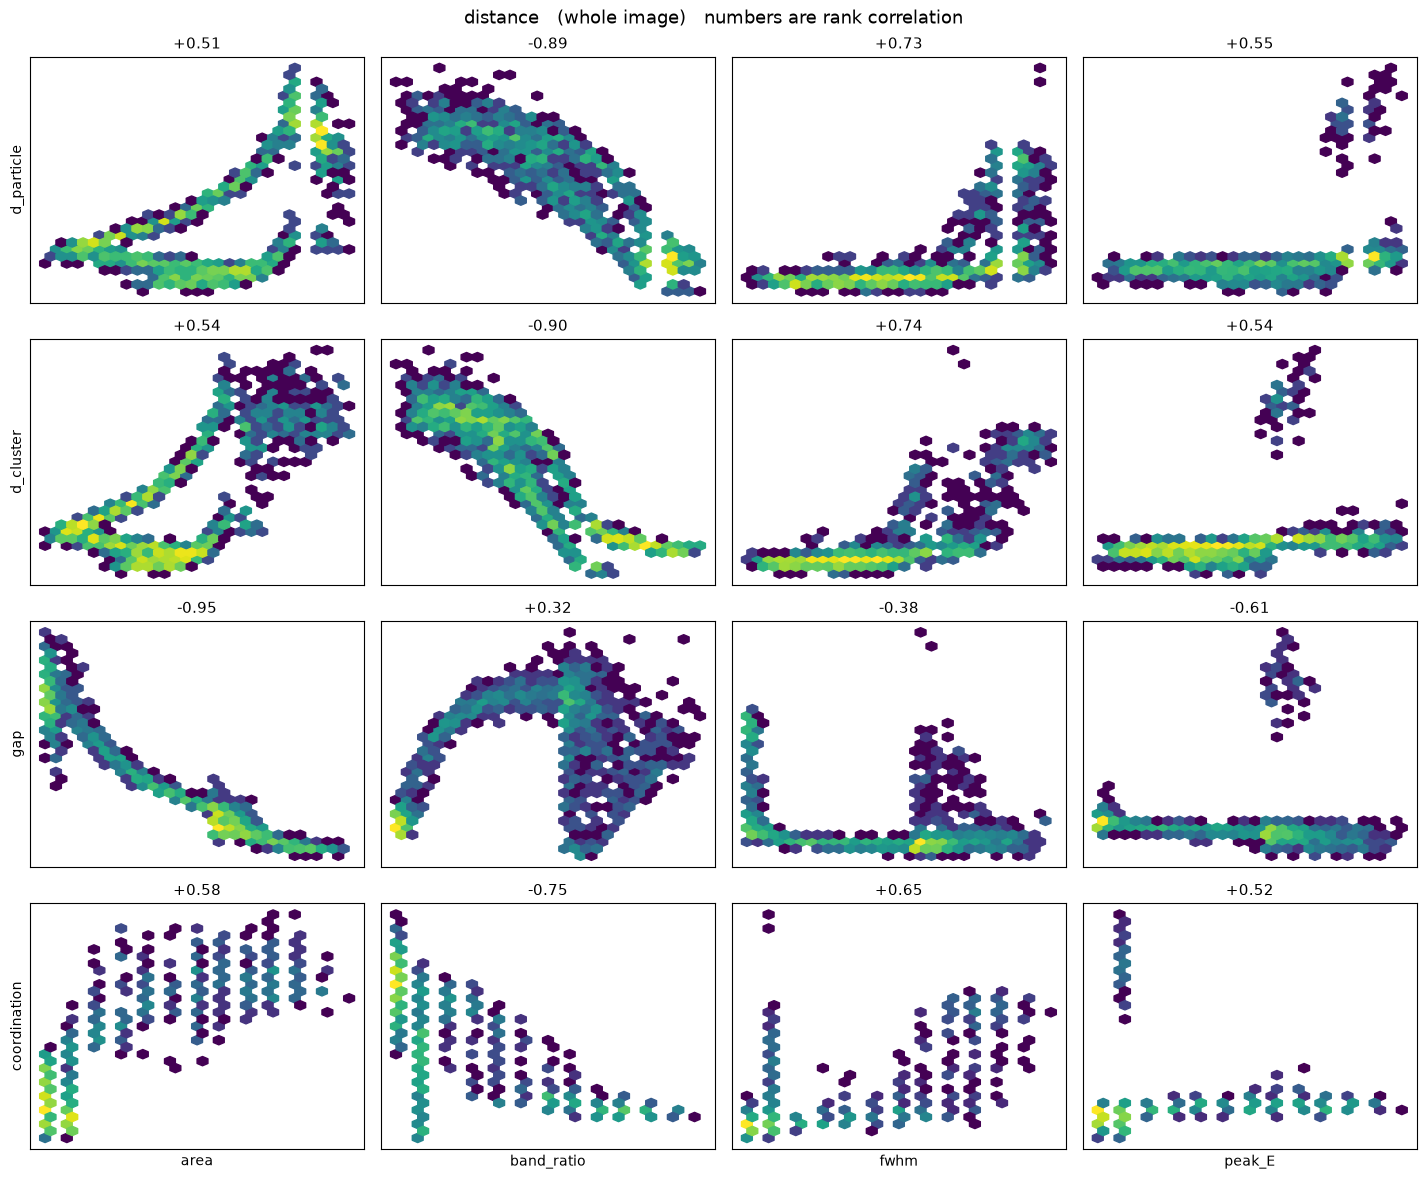

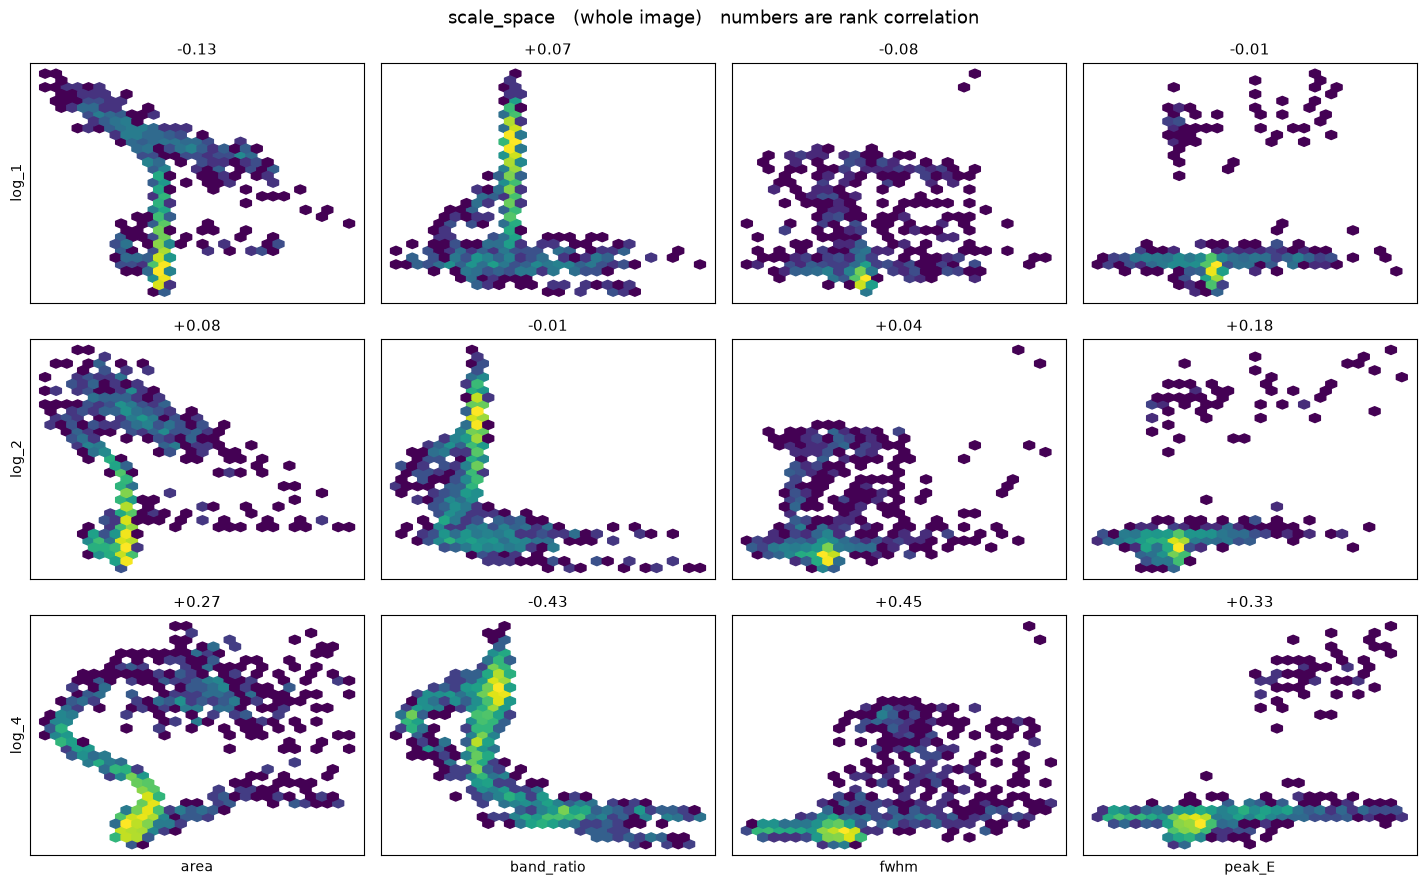

In [23]:
import pandas as pd

# Only the features that carry something. Dropped on purpose:
#   particle_radius   - all particles are the same size, correlation ~0
#   cluster_curvature - acts as a label for "near the isolated particle"
#   mask              - a coarse version of d_cluster
FEATURE_GROUPS = {
    "local_stats": ["mean_5", "std_5", "range_5"],
    "rings":       ["ring_0_2", "ring_2_4", "ring_4_8"],
    "distance":    ["d_particle", "d_cluster", "gap", "coordination"],
    "scale_space": ["log_1", "log_2", "log_4"],
}

TARGETS_TO_SHOW = ["area", "band_ratio", "fwhm", "peak_E"]


def _crop(m, border):
    return m[border:H - border, border:W - border].ravel()


def _keep_mask(border, max_dist):
    """Which points to use. max_dist keeps only points near a particle surface."""
    if max_dist is None:
        return np.ones(_crop(FEATURE_MAPS["d_particle"], border).shape, bool)
    return np.abs(_crop(FEATURE_MAPS["d_particle"], border)) <= max_dist


def _rank_corr(x, y):
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 20 or np.std(x[ok]) == 0 or np.std(y[ok]) == 0:
        return np.nan
    return np.corrcoef(np.argsort(np.argsort(x[ok])),
                       np.argsort(np.argsort(y[ok])))[0, 1]


def group_vs_targets(group, targets=TARGETS_TO_SHOW, border=BORDER,
                     max_dist=None, gridsize=28):
    """One figure per feature group: rows are features, columns are targets.

    max_dist=None uses the whole image.
    max_dist=10 keeps only points within 10 px of a particle surface, which
    removes the far vacuum that otherwise dominates every correlation.
    """
    names = FEATURE_GROUPS[group]
    keep = _keep_mask(border, max_dist)

    fig, axes = plt.subplots(len(names), len(targets),
                             figsize=(3.6 * len(targets), 3.0 * len(names)),
                             squeeze=False)

    for i, f in enumerate(names):
        x_all = _crop(FEATURE_MAPS[f], border)[keep]
        for j, t in enumerate(targets):
            y_all = _crop(SPECTRAL_TARGETS[t], border)[keep]
            ok = np.isfinite(x_all) & np.isfinite(y_all)
            a = axes[i][j]
            a.hexbin(x_all[ok], y_all[ok], gridsize=gridsize,
                     cmap="viridis", bins="log")
            a.set_title(f"{_rank_corr(x_all, y_all):+.2f}", fontsize=11)
            if j == 0:
                a.set_ylabel(f, fontsize=10)
            if i == len(names) - 1:
                a.set_xlabel(t, fontsize=10)
            a.set_xticks([]); a.set_yticks([])

    span = "whole image" if max_dist is None else f"within {max_dist} px of a surface"
    fig.suptitle(f"{group}   ({span})   numbers are rank correlation",
                 fontsize=13)
    plt.tight_layout()
    plt.show()


# ---- look at one group at a time ----
for g in FEATURE_GROUPS:
    group_vs_targets(g)

In [24]:
def compare_groups(targets=TARGETS_TO_SHOW, border=BORDER, max_dist=None):
    """Best feature in each group, for each target.

    Returns two tables: the strongest rank correlation reached by the group,
    and which feature reached it.
    """
    best_r, best_f = {}, {}
    keep = _keep_mask(border, max_dist)

    for g, names in FEATURE_GROUPS.items():
        rr, ff = {}, {}
        for t in targets:
            y = _crop(SPECTRAL_TARGETS[t], border)[keep]
            scores = {f: _rank_corr(_crop(FEATURE_MAPS[f], border)[keep], y)
                      for f in names}
            win = max(scores, key=lambda k: abs(scores[k]) if np.isfinite(scores[k])
                      else -1)
            rr[t], ff[t] = round(scores[win], 2), win
        best_r[g], best_f[g] = rr, ff

    return pd.DataFrame(best_r).T[targets], pd.DataFrame(best_f).T[targets]


print("=== whole image ===")
r_all, f_all = compare_groups()
print(r_all, "\n"); print(f_all)

print("\n=== only within 10 px of a particle surface ===")
r_near, f_near = compare_groups(max_dist=10)
print(r_near, "\n"); print(f_near)

print("\n=== how much each group loses when the far vacuum is removed ===")
print((r_near.abs() - r_all.abs()).round(2))

=== whole image ===
             area  band_ratio  fwhm  peak_E
local_stats  0.68       -0.62  0.61    0.58
rings        0.70       -0.77  0.65    0.59
distance    -0.95       -0.90  0.74   -0.61
scale_space  0.27       -0.43  0.45    0.33 

                 area band_ratio       fwhm    peak_E
local_stats    mean_5    range_5     mean_5    mean_5
rings        ring_2_4   ring_4_8   ring_2_4  ring_2_4
distance          gap  d_cluster  d_cluster       gap
scale_space     log_4      log_4      log_4     log_4

=== only within 10 px of a particle surface ===
             area  band_ratio  fwhm  peak_E
local_stats  0.75       -0.73  0.70    0.65
rings        0.79       -0.76  0.74    0.65
distance    -0.94       -0.87  0.77    0.66
scale_space  0.27       -0.79  0.66    0.40 

                 area band_ratio       fwhm      peak_E
local_stats    mean_5     mean_5     mean_5      mean_5
rings        ring_2_4   ring_2_4   ring_2_4    ring_0_2
distance          gap  d_cluster  d_cluster  d_pa

In [25]:
NEAR = 10          # restrict to the region where the relation is sharpest
GOOD = ["mean_5", "std_5", "range_5",
        "ring_0_2", "ring_2_4", "ring_4_8",
        "d_particle", "d_cluster", "gap", "coordination",
        "log_1", "log_2", "log_4"]


def feature_redundancy(names=GOOD, border=BORDER, max_dist=NEAR):
    """How much do the features repeat each other? Rank correlation between them."""
    keep = _keep_mask(border, max_dist)
    cols = {f: _crop(FEATURE_MAPS[f], border)[keep] for f in names}
    return pd.DataFrame(
        {a: {b: round(_rank_corr(cols[a], cols[b]), 2) for b in names}
         for a in names})[names].loc[names]


def partial_on(control, target, names=GOOD, border=BORDER, max_dist=NEAR):
    """What each feature still explains after the control feature is removed.

    Near zero everywhere means the control already contains all the
    structural information, and the extra features are repeating it.
    """
    keep = _keep_mask(border, max_dist)
    rank = lambda m: np.argsort(np.argsort(
        _crop(m, border)[keep])).astype(float)

    c = rank(FEATURE_MAPS[control])
    resid = lambda u: u - np.polyval(np.polyfit(c, u, 1), c)
    t = resid(rank(SPECTRAL_TARGETS[target]))

    out = {f: round(float(np.corrcoef(resid(rank(FEATURE_MAPS[f])), t)[0, 1]), 2)
           for f in names if f != control}
    return pd.Series(out, name=f"{target} | {control} removed") \
             .sort_values(key=abs, ascending=False)


print("--- how redundant are the features (within 10 px) ---")
print(feature_redundancy())

for control, target in [("gap", "area"),
                        ("d_cluster", "band_ratio"),
                        ("d_particle", "peak_E")]:
    print(f"\n--- {target}, after removing {control} ---")
    print(partial_on(control, target).head(6))

--- how redundant are the features (within 10 px) ---
              mean_5  std_5  range_5  ring_0_2  ring_2_4  ring_4_8  \
mean_5          1.00   0.76     0.80      0.98      0.95      0.77   
std_5           0.76   1.00     0.96      0.73      0.76      0.60   
range_5         0.80   0.96     1.00      0.77      0.80      0.66   
ring_0_2        0.98   0.73     0.77      1.00      0.90      0.73   
ring_2_4        0.95   0.76     0.80      0.90      1.00      0.84   
ring_4_8        0.77   0.60     0.66      0.73      0.84      1.00   
d_particle      0.83   0.77     0.79      0.81      0.87      0.87   
d_cluster       0.85   0.74     0.78      0.82      0.90      0.92   
gap            -0.76  -0.59    -0.64     -0.74     -0.79     -0.80   
coordination    0.73   0.57     0.60      0.70      0.77      0.91   
log_1           0.05  -0.06    -0.07      0.16     -0.10     -0.10   
log_2           0.34   0.26     0.24      0.41      0.17     -0.04   
log_4           0.67   0.66     0.67

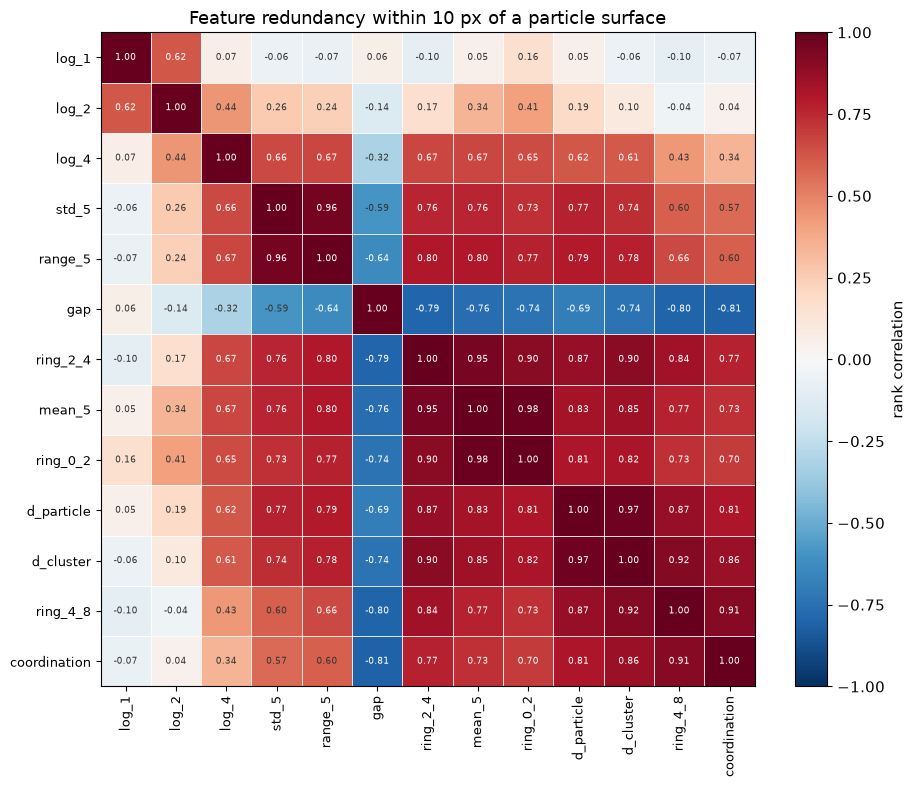

In [26]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform


def plot_redundancy(R, title="Feature redundancy (rank correlation)"):
    """Heatmap of the feature-feature correlations, ordered by similarity.

    Features that repeat each other end up next to each other, so blocks of
    strong colour along the diagonal are groups that say the same thing.
    Zero is white, so you can see at a glance what is independent.
    """
    names = list(R.columns)

    # Distance = how much information two features do NOT share.
    D = 1.0 - R.abs().values
    D = (D + D.T) / 2.0
    np.fill_diagonal(D, 0.0)
    order = leaves_list(linkage(squareform(D, checks=False), method="average"))

    Rm = R.iloc[order, order]
    labels = [names[i] for i in order]

    fig, ax = plt.subplots(figsize=(9.5, 8))
    im = ax.imshow(Rm.values, cmap="RdBu_r", vmin=-1, vmax=1)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)

    # Write the number in each cell, in white where the colour is dark.
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = Rm.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if abs(v) > 0.6 else "0.2")

    # Thin grid so the blocks are easy to separate.
    ax.set_xticks(np.arange(-.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.6)
    ax.tick_params(which="minor", length=0)

    plt.colorbar(im, ax=ax, fraction=0.046, label="rank correlation")
    ax.set_title(title)
    pltt = plt.tight_layout(); plt.show()


R = feature_redundancy()
plot_redundancy(R, "Feature redundancy within 10 px of a particle surface")

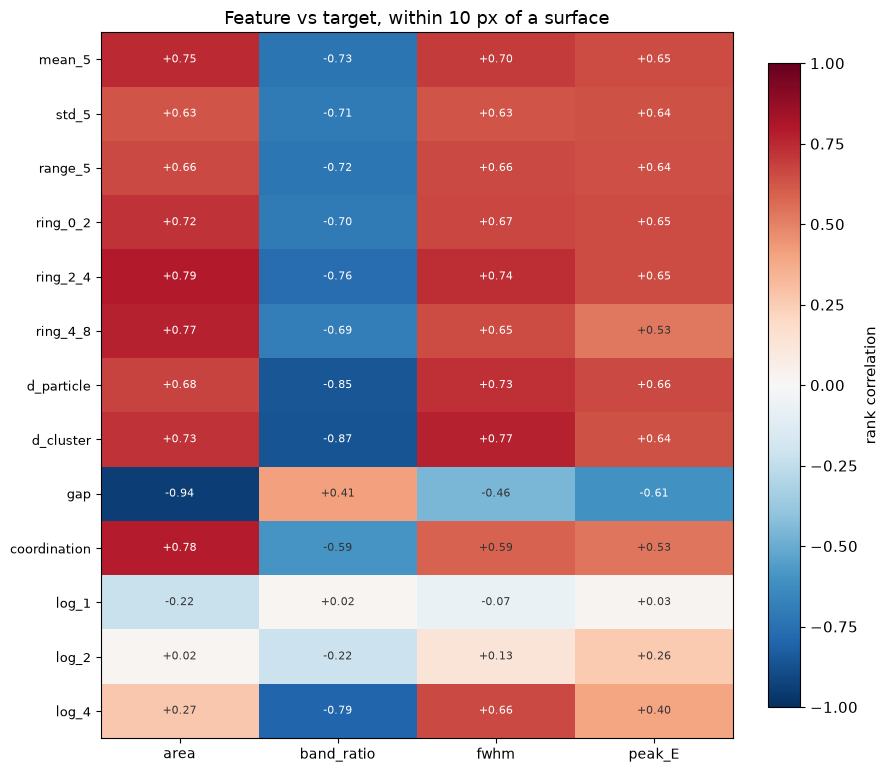

In [27]:
def plot_feature_target(names=GOOD, targets=TARGETS_TO_SHOW,
                        border=BORDER, max_dist=NEAR):
    """Rank correlation of each feature with each target, as a heatmap."""
    keep = _keep_mask(border, max_dist)
    M = pd.DataFrame(
        {t: {f: _rank_corr(_crop(FEATURE_MAPS[f], border)[keep],
                           _crop(SPECTRAL_TARGETS[t], border)[keep])
             for f in names} for t in targets})[targets].loc[names]

    fig, ax = plt.subplots(figsize=(1.5 * len(targets) + 3, 0.45 * len(names) + 2))
    im = ax.imshow(M.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

    ax.set_xticks(range(len(targets))); ax.set_xticklabels(targets, fontsize=10)
    ax.set_yticks(range(len(names)));   ax.set_yticklabels(names, fontsize=9)

    for i in range(len(names)):
        for j in range(len(targets)):
            v = M.values[i, j]
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(v) > 0.6 else "0.2")

    plt.colorbar(im, ax=ax, fraction=0.046, label="rank correlation")
    ax.set_title(f"Feature vs target, within {max_dist} px of a surface")
    plt.tight_layout(); plt.show()
    return M


M = plot_feature_target()

In [24]:
import pandas as pd

def rank_table(border=BORDER):
    """Rank correlation of every feature map with every spectral target."""
    sl = (slice(border, H - border), slice(border, W - border))

    def rc(a, b):
        a, b = a[sl].ravel(), b[sl].ravel()
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() < 10 or np.std(a[ok]) == 0:
            return np.nan
        return np.corrcoef(np.argsort(np.argsort(a[ok])),
                           np.argsort(np.argsort(b[ok])))[0, 1]

    return pd.DataFrame(
        {t: {f: rc(FEATURE_MAPS[f], SPECTRAL_TARGETS[t]) for f in FEATURE_MAPS}
         for t in SPECTRAL_TARGETS}
    ).round(2)

tbl = rank_table()
print(tbl.sort_values("area", key=abs, ascending=False))

                 area  peak_E  peak_I  fwhm     Q  band_ratio
curvature       -0.75   -0.41   -0.75 -0.21  0.18        0.07
ring_2_4         0.70    0.59    0.52  0.65 -0.57       -0.66
mean_5           0.68    0.58    0.49  0.61 -0.53       -0.61
ring_0_2         0.66    0.57    0.48  0.58 -0.50       -0.58
ring_4_8         0.63    0.52    0.48  0.65 -0.60       -0.77
range_5          0.57    0.54    0.37  0.60 -0.51       -0.62
std_5            0.54    0.54    0.35  0.58 -0.49       -0.62
signed_distance  0.54    0.54    0.34  0.74 -0.67       -0.90
mask             0.43    0.36    0.28  0.44 -0.42       -0.38
abs_distance    -0.29   -0.38   -0.20 -0.50  0.40        0.70
log_4            0.27    0.33    0.01  0.45 -0.40       -0.43
gap             -0.24   -0.07   -0.38  0.36 -0.41       -0.42
log_1           -0.13   -0.01   -0.17 -0.08  0.08        0.07
log_2            0.08    0.18   -0.02  0.04  0.02       -0.01


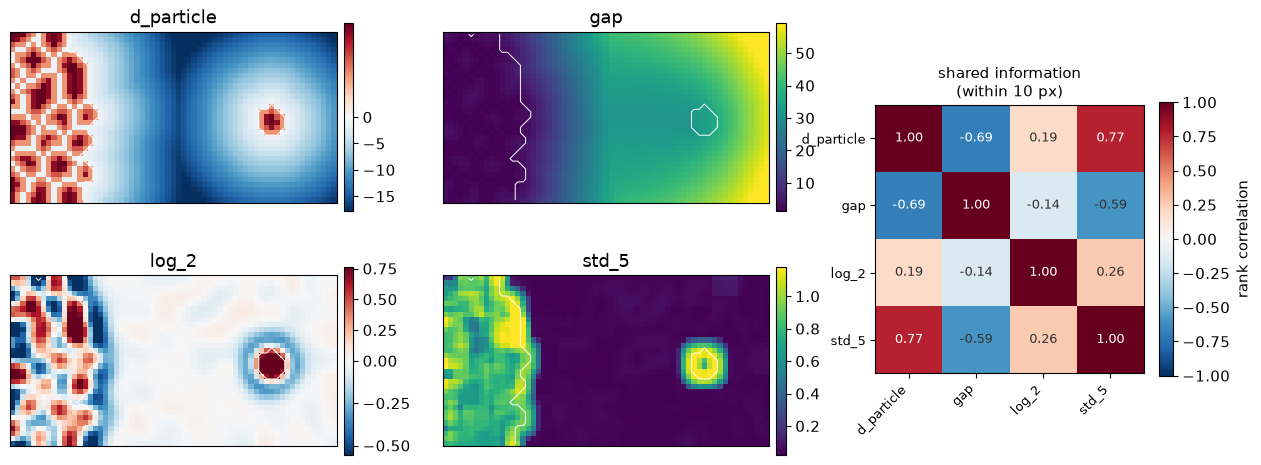

            d_particle   gap  log_2  std_5
d_particle        1.00 -0.69   0.19   0.77
gap              -0.69  1.00  -0.14  -0.59
log_2             0.19 -0.14   1.00   0.26
std_5             0.77 -0.59   0.26   1.00


In [28]:
SELECTED = ["d_particle", "gap", "log_2", "std_5"]


def plot_selected(names=SELECTED, max_dist=NEAR):
    """The four chosen features: their maps, and how much they repeat each other.

    The particle outline is drawn on every map so each one can be read
    against the geometry it came from.
    """
    fig = plt.figure(figsize=(15, 5.6))
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.85], wspace=0.25, hspace=0.3)

    # --- the four maps ---
    for k, n in enumerate(names):
        ax = fig.add_subplot(gs[k // 2, k % 2])
        show_map(ax, FEATURE_MAPS[n], n, mask=mask)

    # --- how independent are they ---
    ax = fig.add_subplot(gs[:, 2])
    keep = _keep_mask(BORDER, max_dist)
    cols = {n: _crop(FEATURE_MAPS[n], BORDER)[keep] for n in names}
    R = np.array([[_rank_corr(cols[a], cols[b]) for b in names] for a in names])

    im = ax.imshow(R, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45,
                                                         ha="right", fontsize=9)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)

    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f"{R[i, j]:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(R[i, j]) > 0.6 else "0.2")

    ax.set_title(f"shared information\n(within {max_dist} px)", fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, label="rank correlation")

    plt.show()
    return pd.DataFrame(R, index=names, columns=names).round(2)


print(plot_selected())

In [29]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score

CANDIDATES = ["d_particle", "gap", "log_2", "std_5"]


def make_xy_near(names, target_name, border=BORDER, max_dist=NEAR):
    """Feature matrix, target and coordinates, restricted to the near region."""
    ys, xs = np.mgrid[border:H - border, border:W - border]
    keep = _keep_mask(border, max_dist)

    X = np.stack([_crop(FEATURE_MAPS[n], border)[keep] for n in names], axis=1)
    y = _crop(SPECTRAL_TARGETS[target_name], border)[keep]
    coords = np.stack([ys.ravel()[keep], xs.ravel()[keep]], axis=1)

    ok = np.isfinite(X).all(axis=1) & np.isfinite(y)
    return X[ok], y[ok], coords[ok]


def spatial_block_split(coords, block=6, test_fraction=0.3, seed=0):
    """Split by square blocks, not by pixels.

    Neighbouring points overlap, so a random pixel split puts nearly identical
    samples in both sets and the score comes out far too good.
    """
    bid = (coords[:, 0] // block) * 10_000 + (coords[:, 1] // block)
    uniq = np.unique(bid)
    rng = np.random.default_rng(seed)
    test = rng.choice(uniq, size=max(1, int(len(uniq) * test_fraction)),
                      replace=False)
    is_test = np.isin(bid, test)
    return ~is_test, is_test


def model():
    """Rank-transform then ridge: handles curved but monotone relations
    without giving the model freedom to fit noise."""
    return make_pipeline(QuantileTransformer(output_distribution="normal",
                                             n_quantiles=200),
                         RidgeCV())


def score(names, target_name, seeds=(0, 1, 2, 3, 4)):
    """Mean test R2 over several block splits, so one unlucky split does not decide."""
    X, y, coords = make_xy_near(names, target_name)
    out = []
    for s in seeds:
        tr, te = spatial_block_split(coords, seed=s)
        if te.sum() < 20 or tr.sum() < 20:
            continue
        out.append(r2_score(y[te], model().fit(X[tr], y[tr]).predict(X[te])))
    return float(np.mean(out)), float(np.std(out))


def forward_select(target_name, candidates=CANDIDATES, k_max=4):
    """Add features one at a time, always the one that helps most."""
    chosen, rows = [], []
    for _ in range(k_max):
        best = None
        for c in [c for c in candidates if c not in chosen]:
            m, s = score(chosen + [c], target_name)
            if best is None or m > best[1]:
                best = (c, m, s)
        chosen.append(best[0])
        rows.append({"added": best[0], "n_features": len(chosen),
                     "R2": round(best[1], 3), "sd": round(best[2], 3),
                     "set": " + ".join(chosen)})
    return pd.DataFrame(rows)


for t in ["area", "band_ratio", "fwhm", "peak_E"]:
    print(f"\n=== {t} ===")
    print(forward_select(t).to_string(index=False))


=== area ===
     added  n_features    R2    sd                              set
       gap           1 0.527 0.047                              gap
     std_5           2 0.606 0.044                      gap + std_5
     log_2           3 0.622 0.054              gap + std_5 + log_2
d_particle           4 0.631 0.058 gap + std_5 + log_2 + d_particle

=== band_ratio ===
     added  n_features    R2    sd                              set
d_particle           1 0.497 0.081                       d_particle
       gap           2 0.498 0.096                 d_particle + gap
     log_2           3 0.480 0.092         d_particle + gap + log_2
     std_5           4 0.363 0.385 d_particle + gap + log_2 + std_5

=== fwhm ===
     added  n_features    R2    sd                              set
d_particle           1 0.149 0.113                       d_particle
       gap           2 0.186 0.110                 d_particle + gap
     log_2           3 0.186 0.117         d_particle + gap + log_2


In [30]:
from scipy.ndimage import gaussian_filter1d

def reliability_ceiling(e_max=1.5, border=BORDER, max_dist=NEAR):
    """Highest R2 any model could reach, set by noise in the target itself.

    Odd and even energy channels are two independent measurements of the same
    spectrum. If they only agree to 0.8, no descriptor can beat 0.8.
    The Spearman-Brown step corrects for each half having half the counts.
    """
    s = (energy >= energy.min()) & (energy <= e_max)
    E, I = energy[s], spectra[:, :, s]
    tz = getattr(np, "trapezoid", None) or np.trapz

    out = {}
    for name, half in [("odd", slice(1, None, 2)), ("even", slice(0, None, 2))]:
        Eh, Ih = E[half], I[:, :, half]
        band = lambda a, b: tz(Ih[:, :, (Eh >= a) & (Eh <= b)],
                               Eh[(Eh >= a) & (Eh <= b)], axis=2)
        Ism = gaussian_filter1d(Ih, sigma=8, axis=2)
        out[name] = {
            "area":       tz(Ih, Eh, axis=2),
            "band_ratio": band(0.4, 0.7) / (band(0.7, 1.2) + 1e-12),
            "peak_E":     Eh[np.argmax(Ism, axis=2)],
            "fwhm":       ((Ism > Ism.max(axis=2)[:, :, None] / 2)
                           * np.gradient(Eh)[None, None, :]).sum(axis=2),
        }

    keep = _keep_mask(border, max_dist)
    rows = []
    for t in out["odd"]:
        r = _rank_corr(_crop(out["odd"][t], border)[keep],
                       _crop(out["even"][t], border)[keep])
        rows.append({"target": t, "half_half": round(r, 3),
                     "ceiling_R2": round(2 * r / (1 + r), 3)})   # Spearman-Brown
    return pd.DataFrame(rows)


print(reliability_ceiling())

       target  half_half  ceiling_R2
0        area      1.000       1.000
1  band_ratio      1.000       1.000
2      peak_E      0.992       0.996
3        fwhm      0.998       0.999


In [31]:
from sklearn.ensemble import RandomForestRegressor

def ceiling_vs_selected(target_name, seeds=(0, 1, 2, 3, 4)):
    """Four chosen features against everything, with a model free to be nonlinear."""
    rows = []
    for label, names, mdl in [
        ("selected (4)", SELECTED, model),
        ("all features", GOOD,     model),
        ("all + forest", GOOD,     lambda: RandomForestRegressor(
            n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=0)),
    ]:
        X, y, coords = make_xy_near(names, target_name)
        sc = []
        for s in seeds:
            tr, te = spatial_block_split(coords, seed=s)
            sc.append(r2_score(y[te], mdl().fit(X[tr], y[tr]).predict(X[te])))
        rows.append({"model": label, "n_features": len(names),
                     "R2": round(np.mean(sc), 3), "sd": round(np.std(sc), 3)})
    return pd.DataFrame(rows)


for t in ["area", "band_ratio", "peak_E"]:
    print(f"\n=== {t} ===")
    print(ceiling_vs_selected(t).to_string(index=False))


=== area ===
       model  n_features    R2    sd
selected (4)           4 0.631 0.058
all features          13 0.770 0.029
all + forest          13 0.982 0.005

=== band_ratio ===
       model  n_features    R2    sd
selected (4)           4 0.363 0.385
all features          13 0.669 0.100
all + forest          13 0.905 0.029

=== peak_E ===
       model  n_features     R2    sd
selected (4)           4 -1.689 2.011
all features          13 -1.498 1.493
all + forest          13  0.632 0.184


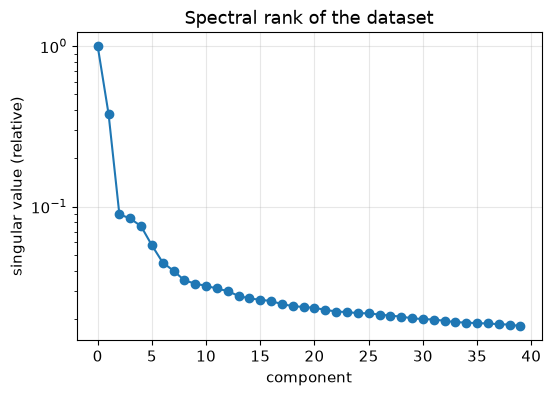

components holding 99% of the variance: 262


In [32]:
# How many independent spectral components are actually in this data?
s = (energy >= energy.min()) & (energy <= 1.5)
M = spectra[:, :, s].reshape(-1, s.sum())
sv = np.linalg.svd(M - M.mean(0), compute_uv=False)

plt.figure(figsize=(6, 4))
plt.semilogy(sv[:40] / sv[0], "o-")
plt.xlabel("component"); plt.ylabel("singular value (relative)")
plt.title("Spectral rank of the dataset"); plt.grid(alpha=0.3); plt.show()

print("components holding 99% of the variance:",
      np.searchsorted(np.cumsum(sv**2) / np.sum(sv**2), 0.99) + 1)

variance explained: [0.813  0.1168 0.0065 0.0058 0.0046 0.0027]
cumulative        : [0.813  0.9298 0.9363 0.9421 0.9468 0.9494]


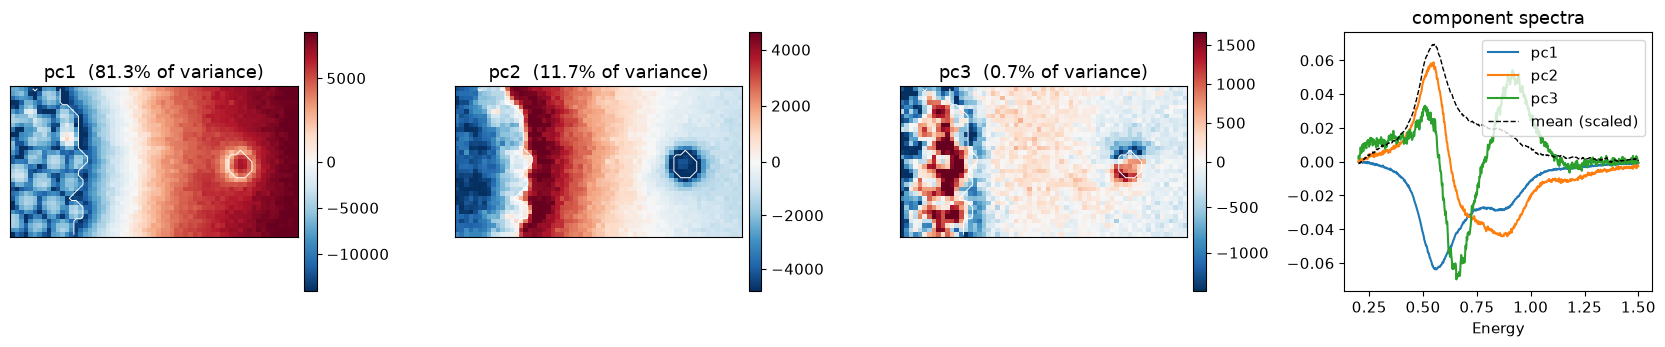

In [33]:
# ---- the real targets: the component weights ----
s = (energy >= energy.min()) & (energy <= 1.5)
Esub = energy[s]
M = spectra[:, :, s].reshape(-1, s.sum())
mu = M.mean(0)

U, S, Vt = np.linalg.svd(M - mu, full_matrices=False)

var = S ** 2 / np.sum(S ** 2)
print("variance explained:", np.round(var[:6], 4))
print("cumulative        :", np.round(np.cumsum(var[:6]), 4))

K = 3
scores = U[:, :K] * S[:K]
for i in range(K):
    SPECTRAL_TARGETS[f"pc{i+1}"] = scores[:, i].reshape(H, W)

# ---- look at them: weights on the left, the component spectra on the right ----
fig, ax = plt.subplots(1, K + 1, figsize=(4.2 * (K + 1), 3.6))
for i in range(K):
    show_map(ax[i], SPECTRAL_TARGETS[f"pc{i+1}"],
             f"pc{i+1}  ({var[i]*100:.1f}% of variance)", mask=mask)
for i in range(K):
    ax[K].plot(Esub, Vt[i], label=f"pc{i+1}")
ax[K].plot(Esub, mu / np.abs(mu).max() * np.abs(Vt[:K]).max(), "k--",
           lw=1, label="mean (scaled)")
ax[K].set_xlabel("Energy"); ax[K].legend(); ax[K].set_title("component spectra")
plt.tight_layout(); plt.show()

In [34]:
def target_is_low_rank(k=2, border=BORDER, max_dist=NEAR):
    """Recompute every target from a rank-k reconstruction and compare.

    Agreement near 1.0 means the target is just a function of the first k
    components and carries nothing extra.
    Poor agreement means the target is living in the noise tail.
    """
    recon = (mu + (U[:, :k] * S[:k]) @ Vt[:k]).reshape(H, W, -1)
    tz = getattr(np, "trapezoid", None) or np.trapz

    def targets_from(I3):
        band = lambda a, b: tz(I3[:, :, (Esub >= a) & (Esub <= b)],
                               Esub[(Esub >= a) & (Esub <= b)], axis=2)
        Ism = gaussian_filter1d(I3, sigma=15, axis=2)
        pk = Ism.max(axis=2)
        return {
            "area":       tz(I3, Esub, axis=2),
            "band_ratio": band(0.4, 0.7) / (band(0.7, 1.2) + 1e-12),
            "peak_E":     Esub[np.argmax(Ism, axis=2)],
            "fwhm":       ((Ism > pk[:, :, None] / 2)
                           * np.gradient(Esub)[None, None, :]).sum(axis=2),
        }

    a = targets_from(spectra[:, :, s])
    b = targets_from(recon)
    keep = _keep_mask(border, max_dist)
    return pd.DataFrame([{"target": t,
                          f"agreement with rank-{k}":
                          round(_rank_corr(_crop(a[t], border)[keep],
                                           _crop(b[t], border)[keep]), 3)}
                         for t in a])


print(target_is_low_rank(2))
print(target_is_low_rank(1))

       target  agreement with rank-2
0        area                  0.996
1  band_ratio                  0.988
2      peak_E                  0.745
3        fwhm                  0.794
       target  agreement with rank-1
0        area                  0.983
1  band_ratio                  0.293
2      peak_E                  0.589
3        fwhm                  0.380


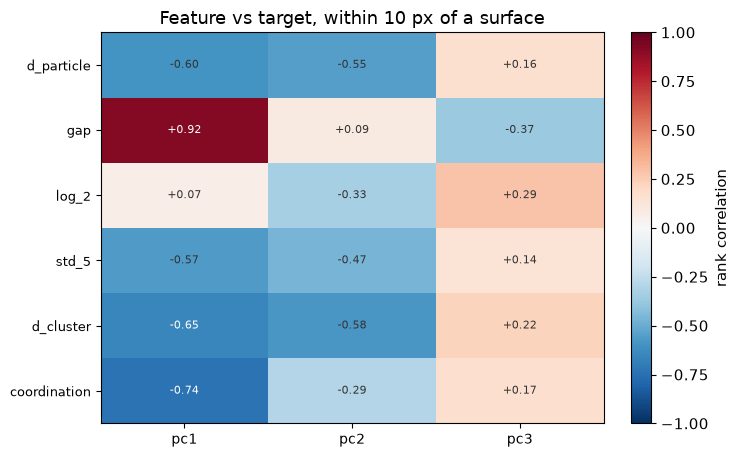

                   pc1       pc2       pc3
d_particle   -0.599623 -0.549905  0.158050
gap           0.919137  0.086792 -0.371207
log_2         0.067723 -0.332220  0.285828
std_5        -0.568817 -0.467431  0.135096
d_cluster    -0.650420 -0.580546  0.219088
coordination -0.740249 -0.293110  0.166077


In [35]:
# Does the image explain both spectral dimensions, or only the first?
print(plot_feature_target(names=SELECTED + ["d_cluster", "coordination"],
                          targets=["pc1", "pc2", "pc3"]))

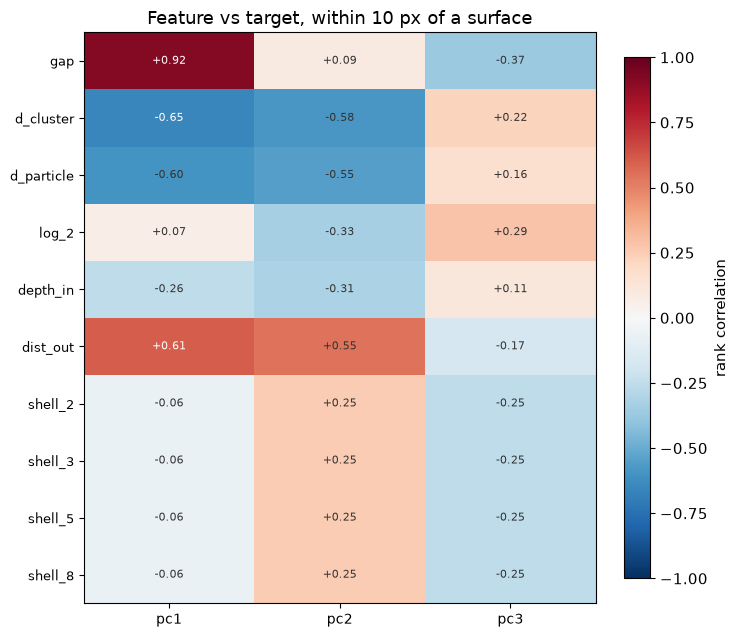

                 pc1       pc2       pc3
gap         0.919137  0.086792 -0.371207
d_cluster  -0.650420 -0.580546  0.219088
d_particle -0.599623 -0.549905  0.158050
log_2       0.067723 -0.332220  0.285828
depth_in   -0.255185 -0.313287  0.110152
dist_out    0.608234  0.546772 -0.167813
shell_2    -0.063127  0.252479 -0.254765
shell_3    -0.063127  0.252479 -0.254765
shell_5    -0.063127  0.252479 -0.254765
shell_8    -0.063127  0.252479 -0.254765


In [37]:
d = FEATURE_MAPS["d_particle"]

# Split the signed distance in two, so inside and outside can behave differently.
FEATURE_MAPS["depth_in"] = np.clip(d, 0, None)     # how deep into the metal
FEATURE_MAPS["dist_out"] = np.clip(-d, 0, None)    # how far out into the vacuum

# A thin shell just outside the surface, where the aloof excitation lives.
for lam in (2, 3, 5, 8):
    FEATURE_MAPS[f"shell_{lam}"] = np.exp(-np.clip(-d, 0, None) / lam) * (d < 0)

INTERFACE = ["depth_in", "dist_out"] + [f"shell_{l}" for l in (2, 3, 5, 8)]

print(plot_feature_target(names=["gap", "d_cluster", "d_particle", "log_2"] + INTERFACE,
                          targets=["pc1", "pc2", "pc3"]))

In [40]:
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

BORDER, NEAR = 4, 10
SELECTED = ["d_particle", "gap", "log_2", "std_5"]

# Position as features: this is the null hypothesis made explicit.
YY, XX = np.mgrid[0:H, 0:W]
FEATURE_MAPS["pos_y"] = YY.astype(float)
FEATURE_MAPS["pos_x"] = XX.astype(float)


def _crop(m):
    return m[BORDER:H - BORDER, BORDER:W - BORDER].ravel()


def make_xy(names, target_name):
    """Features, target and coordinates, near the particle surfaces only."""
    keep = np.abs(_crop(FEATURE_MAPS["d_particle"])) <= NEAR
    ys, xs = np.mgrid[BORDER:H - BORDER, BORDER:W - BORDER]

    X = np.stack([_crop(FEATURE_MAPS[n])[keep] for n in names], axis=1)
    y = _crop(SPECTRAL_TARGETS[target_name])[keep]
    coords = np.stack([ys.ravel()[keep], xs.ravel()[keep]], axis=1)

    ok = np.isfinite(X).all(axis=1) & np.isfinite(y)
    return X[ok], y[ok], coords[ok]


def block_split(coords, block, seed):
    """Hold out whole square blocks, so train and test are far apart."""
    bid = (coords[:, 0] // block) * 10_000 + (coords[:, 1] // block)
    uniq = np.unique(bid)
    rng = np.random.default_rng(seed)
    test = rng.choice(uniq, size=max(1, int(len(uniq) * 0.3)), replace=False)
    is_test = np.isin(bid, test)
    return ~is_test, is_test


SETS = {"gap only": ["gap"], "4 selected": SELECTED,
        "position only": ["pos_y", "pos_x"]}

for target in ["pc1", "pc2"]:
    rows = []
    for block in (4, 8, 12, 16, 20):
        row = {"block_px": block}
        for label, names in SETS.items():
            X, y, coords = make_xy(names, target)
            scores = []
            for seed in range(5):
                tr, te = block_split(coords, block, seed)
                if te.sum() < 30 or tr.sum() < 30:
                    continue
                f = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                          n_jobs=-1, random_state=0)
                scores.append(r2_score(y[te], f.fit(X[tr], y[tr]).predict(X[te])))
            row[label] = round(float(np.mean(scores)), 3) if scores else np.nan
        rows.append(row)
    print(f"\n=== {target} ===")
    print(pd.DataFrame(rows).to_string(index=False))


=== pc1 ===
 block_px  gap only  4 selected  position only
        4     0.923       0.974          0.924
        8     0.917       0.961          0.883
       12     0.875       0.961          0.842
       16     0.848       0.934          0.852
       20     0.732       0.890         -0.391

=== pc2 ===
 block_px  gap only  4 selected  position only
        4     0.667       0.899          0.927
        8     0.575       0.801          0.885
       12    -0.379       0.881          0.342
       16     0.626       0.795          0.235
       20    -0.273       0.882         -3.207


In [41]:
from itertools import combinations

def score_set(names, target, block=16, seeds=range(5)):
    X, y, coords = make_xy(names, target)
    out = []
    for s in seeds:
        tr, te = block_split(coords, block, s)
        if te.sum() < 30 or tr.sum() < 30:
            continue
        f = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                  n_jobs=-1, random_state=0)
        out.append(r2_score(y[te], f.fit(X[tr], y[tr]).predict(X[te])))
    return float(np.mean(out)), float(np.std(out))

rows = []
for k in (1, 2, 3):
    for c in combinations(SELECTED, k):
        m, s = score_set(list(c), "pc2")
        rows.append({"n": k, "features": " + ".join(c),
                     "R2": round(m, 3), "sd": round(s, 3)})
print(pd.DataFrame(rows).sort_values("R2", ascending=False).to_string(index=False))

 n                   features     R2    sd
 2           d_particle + gap  0.852 0.203
 3   d_particle + gap + std_5  0.838 0.199
 3   d_particle + gap + log_2  0.807 0.266
 2                gap + std_5  0.790 0.229
 3        gap + log_2 + std_5  0.720 0.253
 2                gap + log_2  0.709 0.300
 1                        gap  0.626 0.220
 1                 d_particle -0.181 0.455
 2         d_particle + log_2 -0.200 0.554
 3 d_particle + log_2 + std_5 -0.225 0.508
 2         d_particle + std_5 -0.304 0.495
 2              log_2 + std_5 -0.489 0.695
 1                      std_5 -0.671 0.742
 1                      log_2 -0.722 0.997


In [42]:
for names in [["gap"], ["d_particle"], ["gap", "d_particle"]]:
    m, s = score_set(names, "pc1")
    print(f"pc1  {' + '.join(names):25s}  R2 = {m:.3f} ± {s:.3f}")

pc1  gap                        R2 = 0.848 ± 0.200
pc1  d_particle                 R2 = -0.251 ± 0.699
pc1  gap + d_particle           R2 = 0.923 ± 0.110


In [43]:
FINAL = ["gap", "d_particle"]


def make_xy_multi(names, targets):
    """Features and several targets on the same points, near the surfaces."""
    keep = np.abs(_crop(FEATURE_MAPS["d_particle"])) <= NEAR
    ys, xs = np.mgrid[BORDER:H - BORDER, BORDER:W - BORDER]

    X = np.stack([_crop(FEATURE_MAPS[n])[keep] for n in names], axis=1)
    Y = {t: _crop(SPECTRAL_TARGETS[t])[keep] for t in targets}
    coords = np.stack([ys.ravel()[keep], xs.ravel()[keep]], axis=1)

    ok = np.isfinite(X).all(axis=1)
    for t in targets:
        ok &= np.isfinite(Y[t])
    return X[ok], {t: Y[t][ok] for t in targets}, coords[ok]


def oof_predict(X, y, coords, block=16, n_folds=5, seed=0):
    """Predict every point from a model that never saw its block.

    Blocks are assigned to folds, so the training data for any point is always
    spatially separated from it. This is what makes the maps below honest.
    """
    bid = (coords[:, 0] // block) * 10_000 + (coords[:, 1] // block)
    uniq = np.unique(bid)
    rng = np.random.default_rng(seed)
    fold_of = dict(zip(uniq, rng.permutation(len(uniq)) % n_folds))
    fold = np.array([fold_of[b] for b in bid])

    pred = np.full(len(y), np.nan)
    for k in range(n_folds):
        te = fold == k
        if te.sum() < 5 or (~te).sum() < 30:
            continue
        f = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                  n_jobs=-1, random_state=0)
        pred[te] = f.fit(X[~te], y[~te]).predict(X[te])
    return pred


def to_map(values, coords):
    """Put a list of per-point values back into an image."""
    out = np.full((H, W), np.nan)
    out[coords[:, 0], coords[:, 1]] = values
    return out


X, Y, COORDS = make_xy_multi(FINAL, ["pc1", "pc2"])
PRED = {t: oof_predict(X, Y[t], COORDS) for t in ["pc1", "pc2"]}
print("points used:", len(COORDS))

points used: 977


decomposition rebuilt: (2079, 3)
inside a particle   :    64 candidate points
at the surface      :   364 candidate points
in a junction       :   147 candidate points
out in vacuum       :   340 candidate points


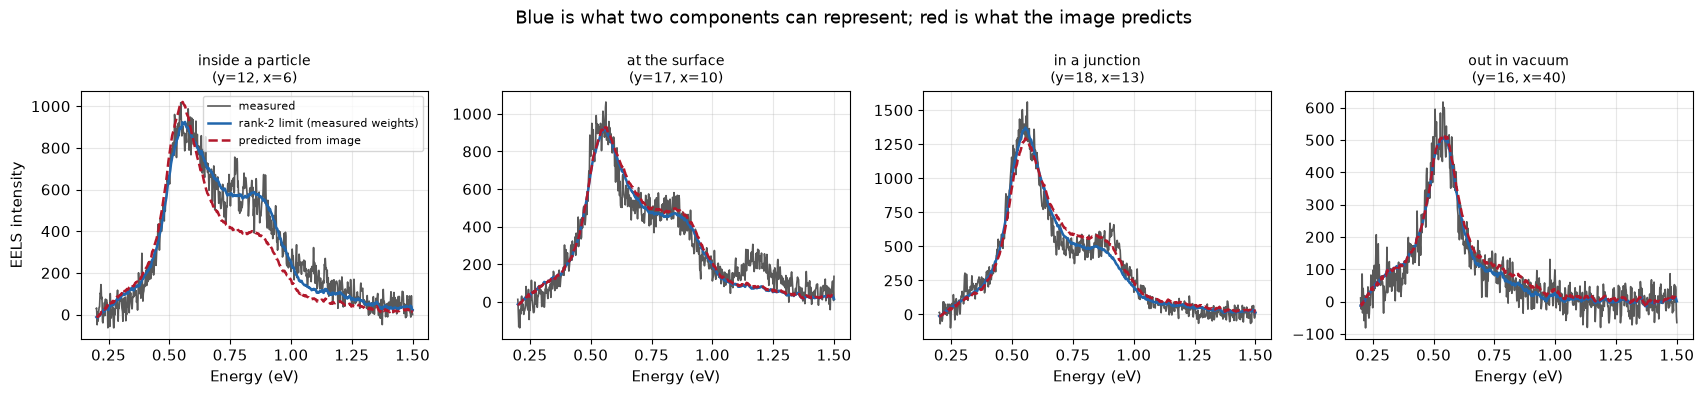

In [50]:
# ============================================================
#  Measured vs predicted spectra at held-out points
#  Self-contained: rebuilds the spectral decomposition under safe names.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. rebuild the spectral decomposition ----------
PC_ESEL   = (energy >= energy.min()) & (energy <= 1.5)
PC_ENERGY = energy[PC_ESEL]

_M = spectra[:, :, PC_ESEL].reshape(-1, int(PC_ESEL.sum()))
PC_MEAN = _M.mean(0)

_U, _S, _V = np.linalg.svd(_M - PC_MEAN, full_matrices=False)
PC_COMPONENTS = _V[:3].copy()          # spectral shape of each component
PC_SCORES     = (_U[:, :3] * _S[:3])   # weight of each component at each pixel

# The sign of an SVD component is arbitrary. Align it with the maps the models
# were trained on, otherwise the comparison below comes out upside down.
for k, nm in enumerate(["pc1", "pc2", "pc3"]):
    if nm in SPECTRAL_TARGETS:
        if np.corrcoef(PC_SCORES[:, k], SPECTRAL_TARGETS[nm].ravel())[0, 1] < 0:
            PC_SCORES[:, k] *= -1
            PC_COMPONENTS[k] *= -1

assert np.allclose(PC_SCORES[:, 0].reshape(H, W), SPECTRAL_TARGETS["pc1"], atol=1e-4)
print("decomposition rebuilt:", PC_SCORES.shape)

# ---------- 2. pick one point in each physical situation ----------
d_pts = FEATURE_MAPS["d_particle"][COORDS[:, 0], COORDS[:, 1]]
g_pts = FEATURE_MAPS["gap"][COORDS[:, 0], COORDS[:, 1]]
ok    = np.isfinite(PRED["pc1"]) & np.isfinite(PRED["pc2"])

outside = d_pts < 0
gap_thr = np.percentile(g_pts[outside], 20)    # narrow gaps, among outside points only

CONDS = [("inside a particle", d_pts >= 2),
         ("at the surface",    np.abs(d_pts) <= 2),
         ("in a junction",     outside & (g_pts <= gap_thr)),
         ("out in vacuum",     d_pts <= -6)]

sel_pts = []
for name, cond in CONDS:
    idx = np.nonzero(cond & ok)[0]
    print(f"{name:20s}: {len(idx):5d} candidate points")
    if len(idx):
        sel_pts.append((name, int(idx[len(idx) // 2])))

# ---------- 3. plot ----------
fig, axes = plt.subplots(1, len(sel_pts), figsize=(4.3 * len(sel_pts), 4.0),
                         sharex=True)
axes = np.atleast_1d(axes)

for a, (name, i) in zip(axes, sel_pts):
    y, x = int(COORDS[i, 0]), int(COORDS[i, 1])
    flat = y * W + x                    # this pixel's row in PC_SCORES

    measured  = spectra[y, x, PC_ESEL]

    # What two components can represent at all, using the MEASURED weights.
    ceiling   = (PC_MEAN
                 + PC_SCORES[flat, 0] * PC_COMPONENTS[0]
                 + PC_SCORES[flat, 1] * PC_COMPONENTS[1])

    # What the two image features predict, from a model that never saw this block.
    predicted = (PC_MEAN
                 + PRED["pc1"][i] * PC_COMPONENTS[0]
                 + PRED["pc2"][i] * PC_COMPONENTS[1])

    a.plot(PC_ENERGY, measured,  color="0.35",   lw=1.2, label="measured")
    a.plot(PC_ENERGY, ceiling,   color="#2166ac", lw=1.8,
           label="rank-2 limit (measured weights)")
    a.plot(PC_ENERGY, predicted, color="#b2182b", lw=1.8, ls="--",
           label="predicted from image")

    a.set_title(f"{name}\n(y={y}, x={x})", fontsize=10)
    a.set_xlabel("Energy (eV)")
    a.grid(alpha=0.3)

axes[0].set_ylabel("EELS intensity")
axes[0].legend(fontsize=8)
fig.suptitle("Blue is what two components can represent; red is what the image predicts",
             fontsize=13)
plt.tight_layout()
plt.show()

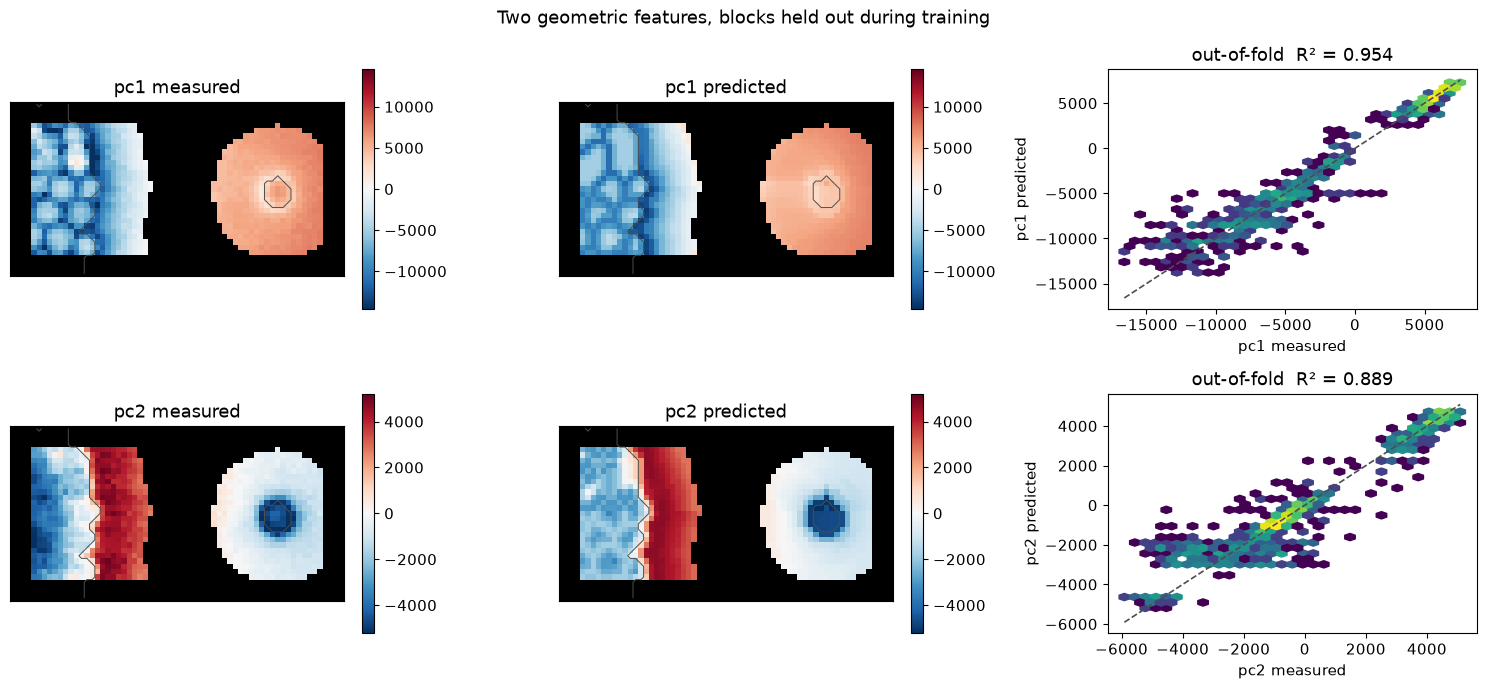

In [45]:
from matplotlib.colors import TwoSlopeNorm

fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for row, t in enumerate(["pc1", "pc2"]):
    truth = to_map(Y[t], COORDS)
    pred = to_map(PRED[t], COORDS)

    # Same colour scale on both maps, otherwise the comparison is meaningless.
    lim = np.nanpercentile(np.abs(truth), 99)
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-lim, vmax=lim)

    for col, (m, label) in enumerate([(truth, "measured"), (pred, "predicted")]):
        a = axes[row][col]
        a.imshow(np.zeros_like(image), cmap="gray", vmin=0, vmax=1)   # dark backdrop
        im = a.imshow(m, cmap="RdBu_r", norm=norm)
        a.contour(mask.astype(float), levels=[0.5], colors="0.3", linewidths=0.7)
        a.set_title(f"{t} {label}")
        a.set_xticks([]); a.set_yticks([])
        plt.colorbar(im, ax=a, fraction=0.046)

    # Parity plot on the held-out predictions.
    a = axes[row][2]
    ok = np.isfinite(PRED[t])
    a.hexbin(Y[t][ok], PRED[t][ok], gridsize=32, cmap="viridis", bins="log")
    lo = min(Y[t][ok].min(), PRED[t][ok].min())
    hi = max(Y[t][ok].max(), PRED[t][ok].max())
    a.plot([lo, hi], [lo, hi], "--", color="0.3", lw=1.2)
    a.set_xlabel(f"{t} measured"); a.set_ylabel(f"{t} predicted")
    a.set_title(f"out-of-fold  R² = {r2_score(Y[t][ok], PRED[t][ok]):.3f}")

fig.suptitle("Two geometric features, blocks held out during training", fontsize=13)
plt.tight_layout(); plt.show()

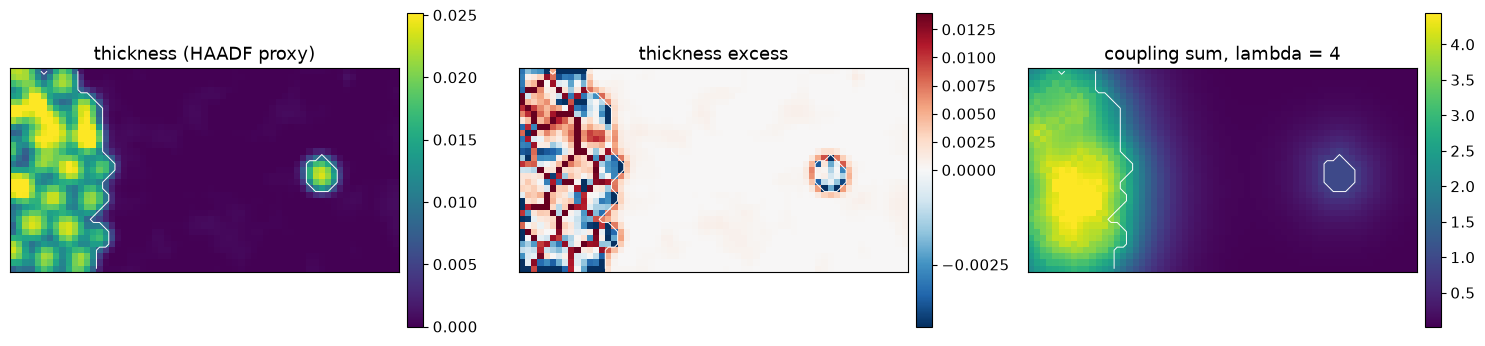

In [53]:
# ---------- complementary feature 1: projected thickness ----------
# HAADF intensity is roughly proportional to how much material the beam crossed.
# Set the vacuum far from the cluster to zero so the numbers mean something.
vac = np.median(image[FEATURE_MAPS["d_particle"] < -6])
FEATURE_MAPS["thickness"] = np.clip(gaussian_filter(image - vac, 0.8), 0, None)

# How much brighter than a single particle of this depth would be.
# Large where the beam crossed more than one particle, which no 2D distance knows.
dep = np.clip(FEATURE_MAPS["d_particle"], 0, None)
expected = np.zeros_like(dep)
inside_m = dep > 0
if inside_m.any():                       # average thickness at each depth
    for v in np.unique(dep[inside_m]):
        expected[dep == v] = FEATURE_MAPS["thickness"][dep == v].mean()
FEATURE_MAPS["thickness_excess"] = FEATURE_MAPS["thickness"] - expected


# ---------- complementary feature 2: coupling from all particles ----------
def coupling_map(labels, lam):
    """Every particle contributes exp(-distance/lam). Generalises d2 to all
    neighbours with one length, instead of stopping at the second one."""
    C = np.zeros(labels.shape)
    for i in range(1, int(labels.max()) + 1):
        C += np.exp(-distance_transform_edt(labels != i) / lam)
    return C

for lam in (2, 4, 8):
    FEATURE_MAPS[f"coup_{lam}"] = coupling_map(LABELS, lam)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
show_map(ax[0], FEATURE_MAPS["thickness"], "thickness (HAADF proxy)", mask=mask)
show_map(ax[1], FEATURE_MAPS["thickness_excess"], "thickness excess", mask=mask)
show_map(ax[2], FEATURE_MAPS["coup_4"], "coupling sum, lambda = 4", mask=mask)
plt.tight_layout(); plt.show()

available: ['d1', 'd2', 'thickness', 'thickness_excess', 'coup_2', 'coup_4', 'coup_8']


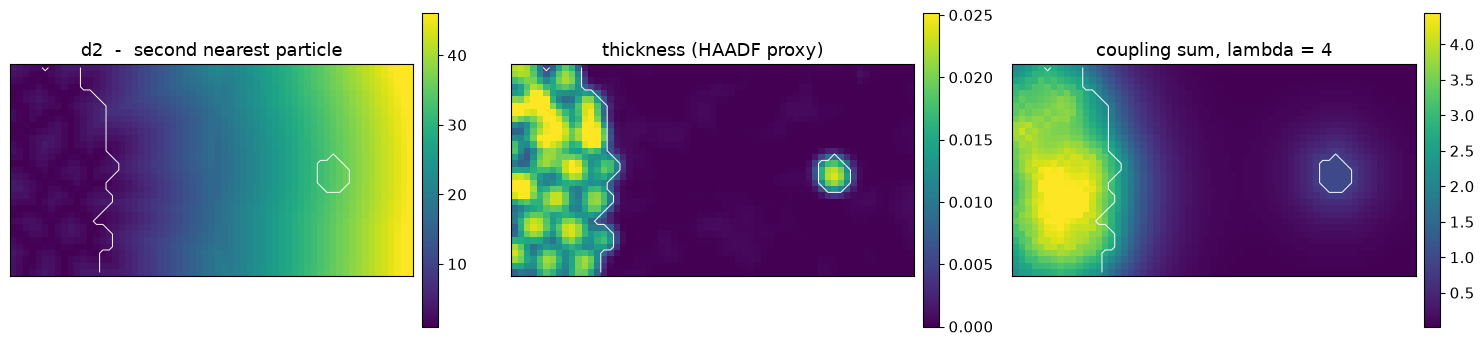


=== pc1 ===
                                      features   all inside outside
                               d_particle + d2 +0.94  -3.70   +0.97
                   d_particle + d2 + thickness +0.95  -3.58   +0.97
d_particle + d2 + thickness + thickness_excess +0.96  -3.51   +0.97
                      d_particle + d2 + coup_4 +0.94  -3.71   +0.96
                                thickness + d2 +0.93  -3.59   +0.94

=== pc2 ===
                                      features   all inside outside
                               d_particle + d2 +0.79  -2.48   +0.91
                   d_particle + d2 + thickness +0.83  -2.18   +0.92
d_particle + d2 + thickness + thickness_excess +0.82  -2.19   +0.92
                      d_particle + d2 + coup_4 +0.81  -2.74   +0.91
                                thickness + d2 +0.81  -2.16   +0.89


In [57]:
# ---------- build the features this test needs ----------
n_part = int(LABELS.max())
DALL = np.sort(np.stack([distance_transform_edt(LABELS != i)
                         for i in range(1, n_part + 1)]), axis=0)
FEATURE_MAPS["d1"] = DALL[0]          # distance to the nearest particle
FEATURE_MAPS["d2"] = DALL[1]          # distance to the second nearest

# Projected thickness: HAADF intensity with the vacuum level set to zero.
vac = np.median(image[FEATURE_MAPS["d_particle"] < -6])
FEATURE_MAPS["thickness"] = np.clip(gaussian_filter(image - vac, 0.8), 0, None)

# How much brighter than typical for this depth: a sign the beam crossed
# more than one particle, which no in-plane distance can know.
dep = np.clip(FEATURE_MAPS["d_particle"], 0, None)
expected = np.zeros_like(dep)
for v in np.unique(dep):
    expected[dep == v] = FEATURE_MAPS["thickness"][dep == v].mean()
FEATURE_MAPS["thickness_excess"] = FEATURE_MAPS["thickness"] - expected

# Coupling from every particle at once, with one decay length.
def coupling_map(labels, lam):
    C = np.zeros(labels.shape)
    for i in range(1, int(labels.max()) + 1):
        C += np.exp(-distance_transform_edt(labels != i) / lam)
    return C

for lam in (2, 4, 8):
    FEATURE_MAPS[f"coup_{lam}"] = coupling_map(LABELS, lam)

print("available:", [k for k in ["d1", "d2", "thickness", "thickness_excess",
                                 "coup_2", "coup_4", "coup_8"]
                     if k in FEATURE_MAPS])

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
show_map(ax[0], FEATURE_MAPS["d2"], "d2  -  second nearest particle", mask=mask)
show_map(ax[1], FEATURE_MAPS["thickness"], "thickness (HAADF proxy)", mask=mask)
show_map(ax[2], FEATURE_MAPS["coup_4"], "coupling sum, lambda = 4", mask=mask)
plt.tight_layout(); plt.show()


# ---------- score by region ----------
def score_region(names, target, region="all", block=8, seeds=range(5)):
    """Score on a subset of points: all of them, inside the metal, or outside."""
    X, Y, coords = make_xy_multi(names, [target])
    d = FEATURE_MAPS["d_particle"][coords[:, 0], coords[:, 1]]
    sub = {"all": np.ones(len(d), bool), "inside": d > 0, "outside": d < 0}[region]
    X, y, coords = X[sub], Y[target][sub], coords[sub]

    out = []
    for s in seeds:
        tr, te = block_split(coords, block, s)
        if te.sum() < 20 or tr.sum() < 40:
            continue
        f = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                  n_jobs=-1, random_state=0)
        out.append(r2_score(y[te], f.fit(X[tr], y[tr]).predict(X[te])))
    return (float(np.mean(out)), float(np.std(out))) if out else (np.nan, np.nan)


TRY = [["d_particle", "d2"],
       ["d_particle", "d2", "thickness"],
       ["d_particle", "d2", "thickness", "thickness_excess"],
       ["d_particle", "d2", "coup_4"],
       ["thickness", "d2"]]

for target in ["pc1", "pc2"]:
    rows = []
    for names in TRY:
        row = {"features": " + ".join(names)}
        for region in ["all", "inside", "outside"]:
            m, _ = score_region(names, target, region)
            row[region] = f"{m:+.2f}" if np.isfinite(m) else "-"
        rows.append(row)
    print(f"\n=== {target} ===")
    print(pd.DataFrame(rows).to_string(index=False))

In [58]:


def score_region(names, target, region="all", block=8, seeds=range(5)):
    """Score on a subset of points: all, inside the metal, or outside it."""
    X, Y, coords = make_xy_multi(names, [target])
    d = FEATURE_MAPS["d_particle"][coords[:, 0], coords[:, 1]]
    sub = {"all": np.ones(len(d), bool), "inside": d > 0, "outside": d < 0}[region]
    X, y, coords = X[sub], Y[target][sub], coords[sub]

    out = []
    for s in seeds:
        tr, te = block_split(coords, block, s)
        if te.sum() < 20 or tr.sum() < 40:
            continue
        f = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                  n_jobs=-1, random_state=0)
        out.append(r2_score(y[te], f.fit(X[tr], y[tr]).predict(X[te])))
    return (float(np.mean(out)), float(np.std(out))) if out else (np.nan, np.nan)


TRY = [["d_particle", "d2"],
       ["d_particle", "d2", "thickness"],
       ["d_particle", "d2", "thickness", "thickness_excess"],
       ["d_particle", "d2", "coup_4"],
       ["thickness", "d2"]]

rows = []
for names in TRY:
    row = {"features": " + ".join(names)}
    for region in ["all", "inside", "outside"]:
        m, sd = score_region(names, "pc2", region)
        row[region] = f"{m:+.2f}" if np.isfinite(m) else "-"
    rows.append(row)
print("pc2 by region\n", pd.DataFrame(rows).to_string(index=False))

pc2 by region
                                       features   all inside outside
                               d_particle + d2 +0.79  -2.48   +0.91
                   d_particle + d2 + thickness +0.83  -2.18   +0.92
d_particle + d2 + thickness + thickness_excess +0.82  -2.19   +0.92
                      d_particle + d2 + coup_4 +0.81  -2.74   +0.91
                                thickness + d2 +0.81  -2.16   +0.89


In [59]:
def pooled_scores(names, target, block=8, n_folds=5):
    """Predict every point out of fold, then score once over the pooled result.

    Scoring each small block separately divides by that block's own variance,
    which is tiny for a uniform patch. Pooling first avoids that.
    """
    X, Y, coords = make_xy_multi(names, [target])
    y = Y[target]
    pred = oof_predict(X, y, coords, block=block, n_folds=n_folds)

    d = FEATURE_MAPS["d_particle"][coords[:, 0], coords[:, 1]]
    rows = []
    for region, sub in [("all", np.ones(len(d), bool)),
                        ("inside", d > 0), ("outside", d < 0)]:
        m = sub & np.isfinite(pred)
        rows.append({"region": region, "n": int(m.sum()),
                     "R2_pooled": round(r2_score(y[m], pred[m]), 3),
                     "corr": round(np.corrcoef(y[m], pred[m])[0, 1], 3),
                     "target_sd": round(float(np.std(y[m])), 1)})
    return pd.DataFrame(rows)


def leave_one_particle_out(names, target):
    """Train on the interiors of all particles but one, predict that one.

    This is the natural hold-out for interior points: whole particles, not
    arbitrary squares, so no test set is a uniform sliver of one particle.
    """
    X, Y, coords = make_xy_multi(names, [target])
    y = Y[target]
    pid = LABELS[coords[:, 0], coords[:, 1]]
    inside = pid > 0

    Xi, yi, pi = X[inside], y[inside], pid[inside]
    pred = np.full(len(yi), np.nan)
    for p in np.unique(pi):
        te = pi == p
        if te.sum() < 3 or (~te).sum() < 30:
            continue
        f = RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                  n_jobs=-1, random_state=0)
        pred[te] = f.fit(Xi[~te], yi[~te]).predict(Xi[te])

    ok = np.isfinite(pred)
    return {"n_particles": len(np.unique(pi)), "n_points": int(ok.sum()),
            "R2_pooled": round(r2_score(yi[ok], pred[ok]), 3),
            "corr": round(np.corrcoef(yi[ok], pred[ok])[0, 1], 3)}


for names in [["d_particle", "d2"], ["d_particle", "d2", "thickness"]]:
    print(f"\n### {' + '.join(names)}")
    for t in ["pc1", "pc2"]:
        print(f"\n-- {t}, block hold-out, pooled --")
        print(pooled_scores(names, t).to_string(index=False))
        print(f"-- {t}, leave-one-particle-out (interiors) --")
        print(leave_one_particle_out(names, t))


### d_particle + d2

-- pc1, block hold-out, pooled --
 region   n  R2_pooled  corr  target_sd
    all 977      0.953 0.976     6861.9
 inside 242      0.702 0.838     4291.2
outside 735      0.977 0.988     6927.5
-- pc1, leave-one-particle-out (interiors) --
{'n_particles': 14, 'n_points': 237, 'R2_pooled': -0.191, 'corr': np.float64(0.101)}

-- pc2, block hold-out, pooled --
 region   n  R2_pooled  corr  target_sd
    all 977      0.894 0.945     2787.4
 inside 242      0.262 0.520     1624.3
outside 735      0.933 0.966     2620.5
-- pc2, leave-one-particle-out (interiors) --
{'n_particles': 14, 'n_points': 237, 'R2_pooled': -0.456, 'corr': np.float64(-0.093)}

### d_particle + d2 + thickness

-- pc1, block hold-out, pooled --
 region   n  R2_pooled  corr  target_sd
    all 977      0.970 0.985     6861.9
 inside 242      0.822 0.908     4291.2
outside 735      0.983 0.991     6927.5
-- pc1, leave-one-particle-out (interiors) --
{'n_particles': 14, 'n_points': 237, 'R2_pooled': 0.

In [60]:
FINAL3 = ["d_particle", "d2", "thickness"]

rows = []
for block in (8, 12, 16, 20):
    X, Y, coords = make_xy_multi(FINAL3, ["pc1", "pc2"])
    d = FEATURE_MAPS["d_particle"][coords[:, 0], coords[:, 1]]
    out = d < 0                                   # aloof points only
    X, coords = X[out], coords[out]

    row = {"block_px": block, "n": int(out.sum())}
    for t in ["pc1", "pc2"]:
        y = Y[t][out]
        pred = oof_predict(X, y, coords, block=block, n_folds=5)
        ok = np.isfinite(pred)
        row[t] = round(r2_score(y[ok], pred[ok]), 3)
    # variance-weighted share of the spectrum
    row["spectral"] = round(row["pc1"] * 0.813 + row["pc2"] * 0.117, 3)
    rows.append(row)

print(pd.DataFrame(rows).to_string(index=False))

 block_px   n   pc1   pc2  spectral
        8 735 0.982 0.950     0.910
       12 735 0.977 0.938     0.904
       16 735 0.979 0.937     0.906
       20 735 0.980 0.935     0.906


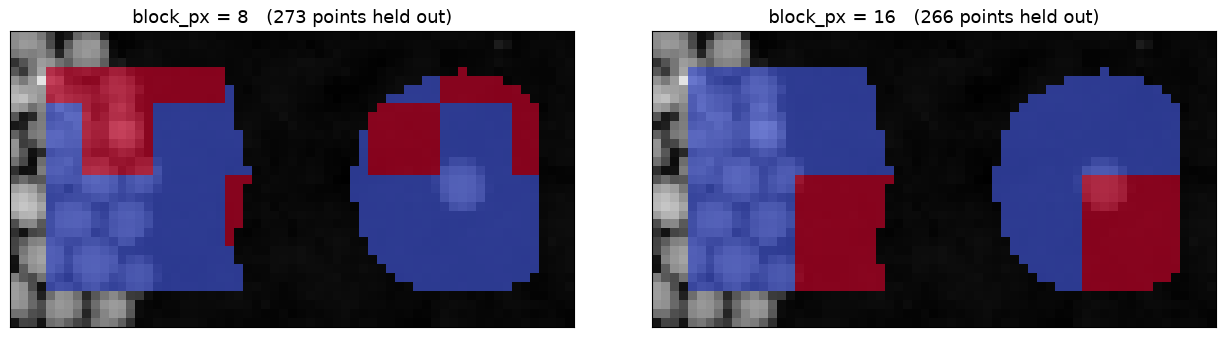

In [61]:
X, Y, coords = make_xy_multi(["d_particle", "d2"], ["pc1"])

fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
for a, b in zip(ax, (8, 16)):
    tr, te = block_split(coords, b, seed=0)
    m = np.full((H, W), np.nan)
    m[coords[tr, 0], coords[tr, 1]] = 0        # training points
    m[coords[te, 0], coords[te, 1]] = 1        # held out
    a.imshow(image, cmap="gray")
    a.imshow(m, cmap="coolwarm", alpha=0.75, vmin=0, vmax=1)
    a.set_title(f"block_px = {b}   ({te.sum()} points held out)")
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## <font color = "purple">**5.**</font> Create Patch–Spectrum–Scalarizer Pairs

For each location we collect:

**Image patch → EELS spectrum → Scalarizer**

The spectrum and scalarizer correspond to the center pixel of the patch.

In [ ]:
PATCH_SIZE = 5
half = PATCH_SIZE // 2

patches = []
targets = []

for y in range(half, H - half):
    for x in range(half, W - half):

        patch = image[y-half:y+half+1, x-half:x+half+1]

        patches.append(patch)
        targets.append(scalarizer_map[y, x])

patches = np.array(patches)
targets = np.array(targets)

print("Patches:", patches.shape)
print("Targets:", targets.shape)

## <font color = "purple">**6.**</font> Look at Example Pairs

Each patch has one target scalarizer value.

Can you see structural differences between low and high target values?

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(10, 3))

ids = np.linspace(0, len(patches) - 1, 4, dtype=int)

for i, idx in enumerate(ids):
    ax[i].imshow(patches[idx], cmap="gray")
    ax[i].set_title(f"Target = {targets[idx]:.2f}")
    ax[i].axis("off")

plt.tight_layout()
plt.show()

## The Challenge

You will design two parts of the prediction pipeline:

**Image Patch → Descriptor → Regressor → EELS Scalarizer**

### Your goal

Find a combination with:

- high predictive power
- low complexity
- good explainability

You can change:

1. the **descriptor** — how the image patch is represented
2. the **regressor** — how the descriptor is mapped to the EELS property

Try different combinations and compare their performance.

## <font color = "purple">**7.**</font> Define Your Descriptor and Regressor

Change only the code inside the marked sections.

The descriptor converts an image patch into features.

The regressor learns how those features relate to the EELS scalarizer.

In [ ]:
def descriptor(patch):

    # ============================================================
    # YOUR CODE STARTS HERE
    # ============================================================

    features = [
        patch.mean(),
        patch.std(),
        patch.max() - patch.min()
    ]

    # ============================================================
    # YOUR CODE ENDS HERE
    # ============================================================

    return features


def regressor():

    # ============================================================
    # YOUR CODE STARTS HERE
    # ============================================================

    model = LinearRegression()

    # ============================================================
    # YOUR CODE ENDS HERE
    # ============================================================

    return model

## <font color = "purple">**8.**</font> Run Your Pipeline

Now we test your descriptor–regressor combination.

The same train/test split is used each time so different combinations can be compared fairly.

In [ ]:
# Build descriptor matrix
X = np.array([descriptor(patch) for patch in patches])

# Same split for every experiment
X_train, X_test, y_train, y_test = train_test_split(
    X,
    targets,
    test_size=0.25,
    random_state=0
)

# Train
model = regressor()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, predictions)

print("Regressor:", type(model).__name__)
print("Number of features:", X.shape[1])
print(f"R²: {r2:.3f}")

## <font color = "purple">**9.**</font> Compare Prediction with Ground Truth

A good model should predict values close to the measured EELS scalarizer.

Points closer to the diagonal line indicate better agreement.

In [ ]:
# Size of valid prediction region
map_shape = (
    H - 2 * half,
    W - 2 * half
)

# Predicted values
predicted = model.predict(X).reshape(map_shape)

# Put predictions back into an image of the original size
prediction_map = np.full((H, W), np.nan)

prediction_map[
    half:H-half,
    half:W-half
] = predicted


fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].imshow(scalarizer_map)
ax[0].set_title("Ground Truth")

ax[1].imshow(prediction_map)
ax[1].set_title("Prediction")

# Test data
ax[2].scatter(y_test, predictions, alpha=0.5)

low = min(y_test.min(), predictions.min())
high = max(y_test.max(), predictions.max())

ax[2].plot([low, high], [low, high], "--")
ax[2].set_xlabel("Ground Truth")
ax[2].set_ylabel("Prediction")
ax[2].set_title(f"Test Data — R² = {r2:.3f}")

plt.tight_layout()
plt.show()

## <font color = "purple">**10.**</font> Compare Descriptor–Regressor Combinations

Test several descriptors and regressors.

Create a heatmap where:

- rows = descriptors
- columns = regressors
- color/value = test R²

Use the same train/test split for every combination.

### <font color = "red">**Goal**</font>

Identify which descriptor–regressor combinations give the strongest predictive performance.

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

## <font color = "purple">**11.**</font> Best Model and Explainability

From the heatmap, identify the best descriptor–regressor combination.

Report:

- best descriptor
- best regressor
- number of descriptor features
- test R²

Then explain:

- What does the descriptor measure?
- Which structural features are important?
- Why might those features be related to the EELS response?

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

### Final question

> Which descriptor–regressor combination gives the best predictive performance while remaining simple and explainable?